In [1]:
# CELL 1 - Install all dependencies
# Run this first, then restart the kernel.

import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

BASE_PACKAGES = [
    "numpy", "pandas", "matplotlib", "seaborn", "scikit-learn",
    "xgboost", "lightgbm", "shap", "umap-learn", "torch", "tqdm",
    "imbalanced-learn", "streamlit", "py3Dmol", "joblib",
    "transformers", "tokenizers",
]


def pip_install(args):
    cmd = [sys.executable, "-m", "pip", "install", "--prefer-binary", *args]
    print("RUN:", " ".join(cmd))
    return subprocess.run(cmd, check=False)


print(f"Python: {sys.executable}")
subprocess.run(
    [sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"],
    check=True,
)

# RDKit
for candidate in ["rdkit-pypi", "rdkit"]:
    if pip_install([candidate]).returncode == 0:
        print(f"RDKit OK: {candidate}")
        break
else:
    raise RuntimeError("RDKit install failed")

# Base packages
for pkg in BASE_PACKAGES:
    pip_install([pkg])

# PyG
if pip_install(["torch-geometric"]).returncode != 0 and IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install",
         "pyg_lib", "torch_scatter", "torch_sparse", "torch_cluster", "torch_spline_conv",
         "-f", "https://data.pyg.org/whl/torch-2.0.0+cu118.html"],
        check=False,
    )
    pip_install(["torch-geometric"])

print("\nDone. RESTART KERNEL NOW, then run Cell 2.")

Python: /usr/bin/python3
RUN: /usr/bin/python3 -m pip install --prefer-binary rdkit-pypi
RUN: /usr/bin/python3 -m pip install --prefer-binary rdkit
RDKit OK: rdkit
RUN: /usr/bin/python3 -m pip install --prefer-binary numpy
RUN: /usr/bin/python3 -m pip install --prefer-binary pandas
RUN: /usr/bin/python3 -m pip install --prefer-binary matplotlib
RUN: /usr/bin/python3 -m pip install --prefer-binary seaborn
RUN: /usr/bin/python3 -m pip install --prefer-binary scikit-learn
RUN: /usr/bin/python3 -m pip install --prefer-binary xgboost
RUN: /usr/bin/python3 -m pip install --prefer-binary lightgbm
RUN: /usr/bin/python3 -m pip install --prefer-binary shap
RUN: /usr/bin/python3 -m pip install --prefer-binary umap-learn
RUN: /usr/bin/python3 -m pip install --prefer-binary torch
RUN: /usr/bin/python3 -m pip install --prefer-binary tqdm
RUN: /usr/bin/python3 -m pip install --prefer-binary imbalanced-learn
RUN: /usr/bin/python3 -m pip install --prefer-binary streamlit
RUN: /usr/bin/python3 -m pip in

In [1]:
# CELL 2 · Dependency Verification (always run after restart)

import importlib
import sys

REQUIRED_MODULES = {
    "rdkit": "rdkit",
    "torch": "torch",
    "torch_geometric": "torch_geometric",
    "xgboost": "xgboost",
    "shap": "shap",
    "umap": "umap",
}

print(f"Python executable: {sys.executable}")
missing = []

for display_name, module_name in REQUIRED_MODULES.items():
    try:
        importlib.import_module(module_name)
        print(f"OK: {display_name}")
    except Exception as exc:
        print(f"MISSING: {display_name} -> {exc}")
        missing.append(display_name)

if missing:
    raise ModuleNotFoundError(
        "Missing required packages: " + ", ".join(missing) + ". "
        "Re-run Cell 1 and restart the kernel before continuing."
    )

print("All required dependencies are available.")

Python executable: /usr/bin/python3
OK: rdkit
OK: torch
OK: torch_geometric
OK: xgboost
OK: shap
OK: umap
All required dependencies are available.


In [3]:
# CELL 3 - Imports + Device Setup (Multi-Model Stacking Ensemble)

import os, sys, warnings, random, json, urllib.request
from contextlib import nullcontext
warnings.filterwarnings("ignore")
random.seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm import tqdm
import joblib

# RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, Draw, rdMolDescriptors, QED
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

# ML — Multi-model
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    roc_curve, precision_recall_curve, confusion_matrix, auc as sklearn_auc,
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import shap

# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau
from torch.optim.swa_utils import AveragedModel, SWALR
try:
    from torch.amp import autocast, GradScaler
except ImportError:
    from torch.cuda.amp import autocast, GradScaler

# PyTorch Geometric
from torch_geometric.data import Data, DataLoader as PyGDataLoader
from torch_geometric.nn import GATConv, GINConv, global_mean_pool, global_add_pool
from torch_geometric.utils import dropout_edge

# UMAP
import umap

# ---------- OUTPUT DIRS ----------
DIRS = {
    "data":        "./data",
    "plots":       "./data/plots",
    "explanations":"./data/explanations",
    "predictions": "./data/predictions",
    "models":      "./models",
    "models_gnn":  "./models/gnn",
    "models_xgb":  "./models/xgboost",
    "models_lgb":  "./models/lightgbm",
    "models_rf":   "./models/randomforest",
    "models_ens":  "./models/ensemble",
    "models_root": "./models",
}
for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | Device: {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    mem_gb = getattr(props, 'total_memory', getattr(props, 'total_mem', 0)) / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)} | Memory: {mem_gb:.1f} GB")
print(f"Multi-model: XGBoost + LightGBM + RandomForest + ToxGNN + ChemBERTa → Stacking Ensemble")

PyTorch 2.10.0+cu128 | CUDA: True | Device: cuda
GPU: Tesla T4 | Memory: 15.6 GB
Multi-model: XGBoost + LightGBM + RandomForest + ToxGNN + ChemBERTa → Stacking Ensemble


In [4]:
# CELL 4 - Download Tox21 (primary) + ZINC250k (secondary) datasets
# Tox21: ~8k compounds, 12 toxicity tasks  (DeepChem mirror, no API key)
# ZINC250k: ~250k drug-like molecules with logP, QED, SAS properties

# ---- Tox21 (primary) ----
TOX21_URL  = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz"
TOX21_PATH = "./data/tox21.csv.gz"

if not os.path.exists(TOX21_PATH):
    print("Downloading Tox21...")
    urllib.request.urlretrieve(TOX21_URL, TOX21_PATH)
df_raw = pd.read_csv(TOX21_PATH)
print(f"Tox21: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")

# ---- ZINC250k (secondary) ----
ZINC_URL  = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
ZINC_PATH = "./data/zinc250k.csv"

if not os.path.exists(ZINC_PATH):
    print("Downloading ZINC250k...")
    urllib.request.urlretrieve(ZINC_URL, ZINC_PATH)
df_zinc = pd.read_csv(ZINC_PATH)
print(f"ZINC250k: {df_zinc.shape[0]} rows x {df_zinc.shape[1]} cols")
print(f"  Columns: {list(df_zinc.columns)}")

# Standardize ZINC column names
zinc_col_map = {}
for c in df_zinc.columns:
    cl = c.strip().lower()
    if "smile" in cl:
        zinc_col_map[c] = "smiles"
    elif "logp" in cl:
        zinc_col_map[c] = "logP"
    elif "qed" in cl:
        zinc_col_map[c] = "qed"
    elif "sas" in cl or "sa_score" in cl or "SAS" in cl:
        zinc_col_map[c] = "sas"
df_zinc.rename(columns=zinc_col_map, inplace=True)

print(f"\nTox21 sample:")
display(df_raw.head(3))
print(f"\nZINC250k sample:")
display(df_zinc.head(3))

Tox21: 7831 rows x 14 cols
ZINC250k: 249455 rows x 4 cols
  Columns: ['smiles', 'logP', 'qed', 'SAS']

Tox21 sample:


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...



ZINC250k sample:


,smiles,logP,qed,sas
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633


In [5]:
# Guardrail - Dataset sanity checks
assert "df_raw" in globals() and len(df_raw) > 0, "Tox21 missing"
assert "df_zinc" in globals() and len(df_zinc) > 0, "ZINC250k missing"
assert ("smiles" in df_raw.columns) or ("mol_id" in df_raw.columns), "No SMILES col in Tox21"
assert "smiles" in df_zinc.columns, "No SMILES col in ZINC250k"
print(f"OK: Tox21={len(df_raw)} rows, ZINC250k={len(df_zinc)} rows")

OK: Tox21=7831 rows, ZINC250k=249455 rows


Tasks: 12 | SMILES col: smiles


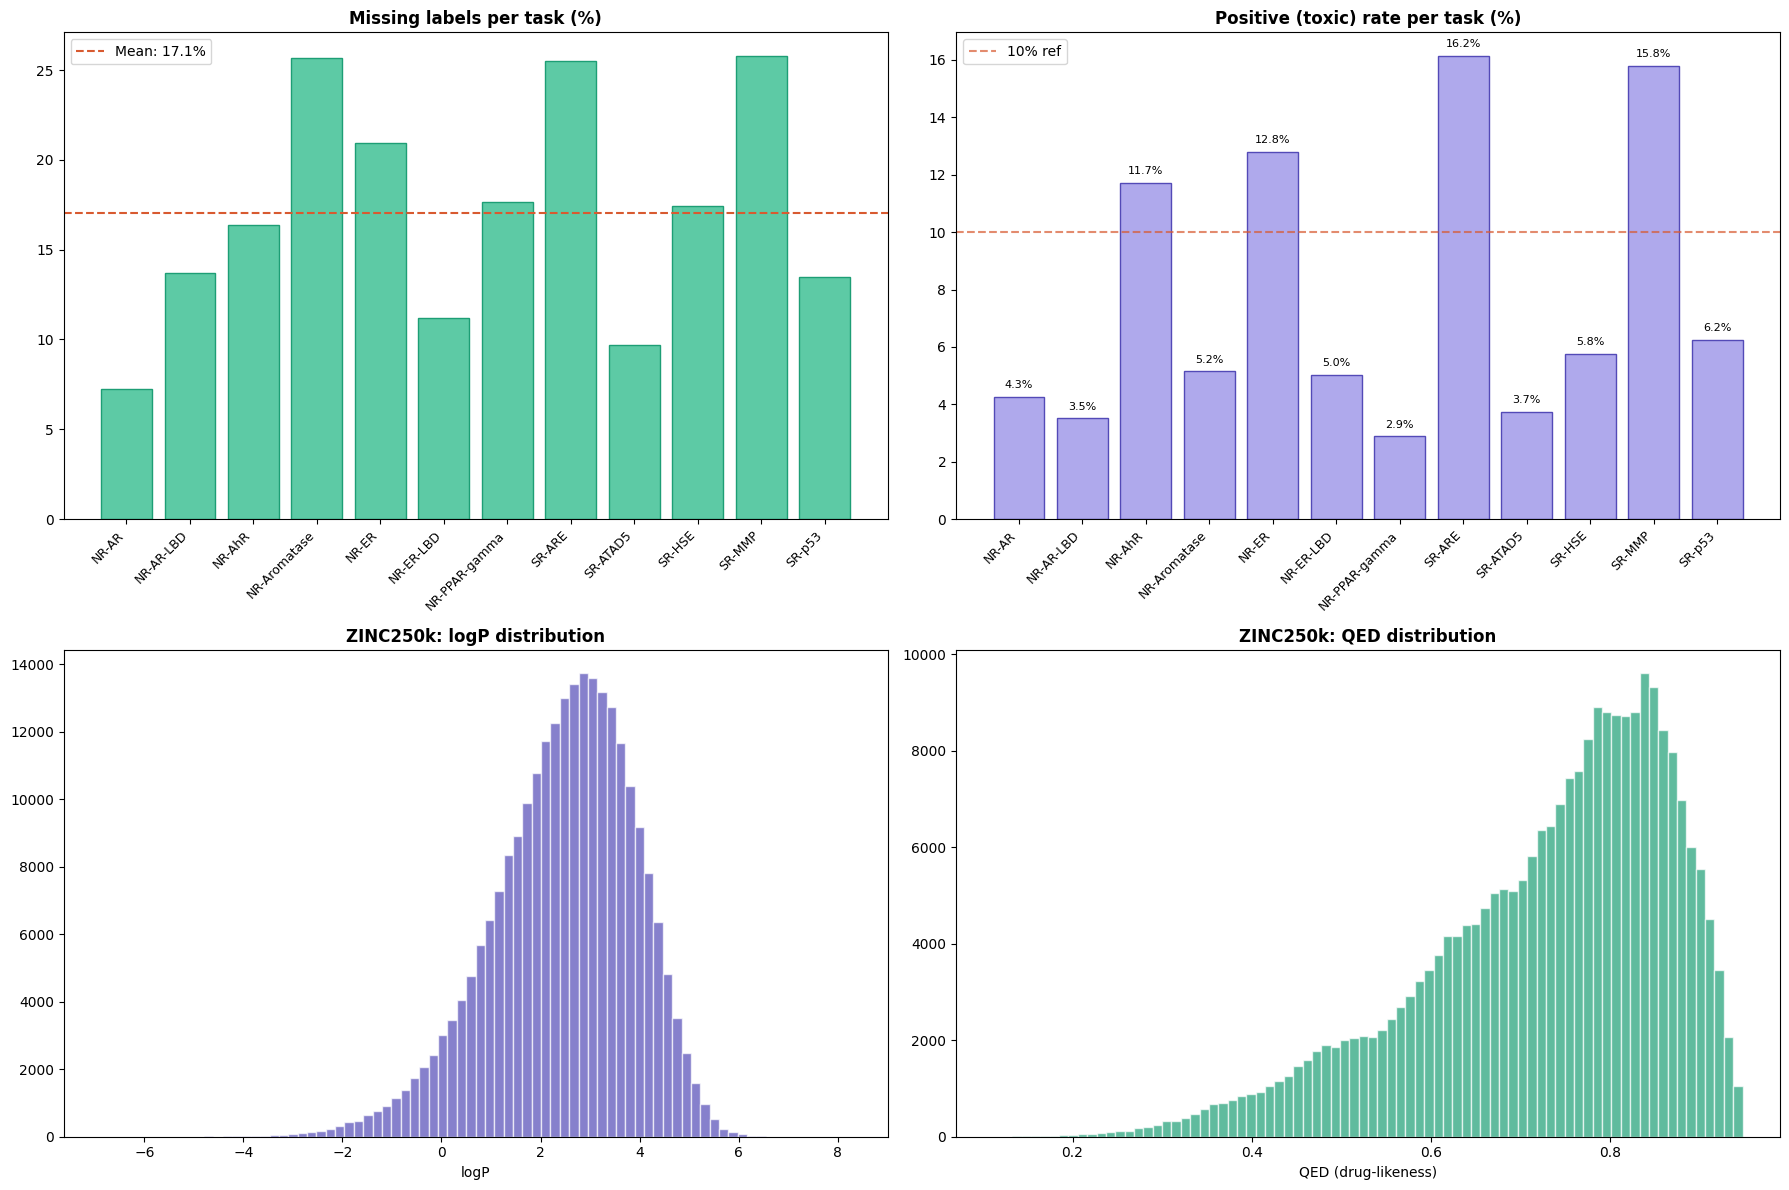

EDA saved to ./data/plots/eda_overview.png


In [6]:
# CELL 6 - Exploratory Data Analysis (Tox21 + ZINC250k)

TOX21_TASKS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase',
    'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]
TOX21_TASKS = [t for t in TOX21_TASKS if t in df_raw.columns]
SMILES_COL = 'smiles' if 'smiles' in df_raw.columns else 'mol_id'
print(f"Tasks: {len(TOX21_TASKS)} | SMILES col: {SMILES_COL}")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Missing labels
missing_pct = df_raw[TOX21_TASKS].isnull().mean() * 100
axes[0,0].bar(TOX21_TASKS, missing_pct, color='#5DCAA5', edgecolor='#1D9E75')
axes[0,0].set_title('Missing labels per task (%)', fontweight='bold')
axes[0,0].set_xticklabels(TOX21_TASKS, rotation=45, ha='right', fontsize=9)
axes[0,0].axhline(missing_pct.mean(), color='#D85A30', ls='--', label=f'Mean: {missing_pct.mean():.1f}%')
axes[0,0].legend()

# 2) Class imbalance
pos_rates = [(df_raw[t].dropna() == 1).mean() * 100 for t in TOX21_TASKS]
bars = axes[0,1].bar(TOX21_TASKS, pos_rates, color='#AFA9EC', edgecolor='#534AB7')
axes[0,1].set_title('Positive (toxic) rate per task (%)', fontweight='bold')
axes[0,1].set_xticklabels(TOX21_TASKS, rotation=45, ha='right', fontsize=9)
axes[0,1].axhline(10, color='#D85A30', ls='--', alpha=0.7, label='10% ref')
for b, r in zip(bars, pos_rates):
    axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{r:.1f}%', ha='center', fontsize=8)
axes[0,1].legend()

# 3) ZINC250k property distributions
if 'logP' in df_zinc.columns:
    axes[1,0].hist(df_zinc['logP'].dropna(), bins=80, color='#534AB7', alpha=0.7, edgecolor='white')
    axes[1,0].set_title('ZINC250k: logP distribution', fontweight='bold')
    axes[1,0].set_xlabel('logP')

if 'qed' in df_zinc.columns:
    axes[1,1].hist(df_zinc['qed'].dropna(), bins=80, color='#1D9E75', alpha=0.7, edgecolor='white')
    axes[1,1].set_title('ZINC250k: QED distribution', fontweight='bold')
    axes[1,1].set_xlabel('QED (drug-likeness)')

plt.tight_layout()
plt.savefig(f'{DIRS["plots"]}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"EDA saved to {DIRS['plots']}/eda_overview.png")

In [7]:
# Guardrail - Task and column checks
assert len(TOX21_TASKS) == 12, f"Expected 12 tasks, got {len(TOX21_TASKS)}"
assert SMILES_COL in df_raw.columns
print(f"OK: {len(TOX21_TASKS)} tasks, SMILES col = {SMILES_COL}")

OK: 12 tasks, SMILES col = smiles


Validating SMILES...


100%|██████████| 7831/7831 [00:01<00:00, 4135.59it/s]


Valid: 7823/7831 (99.9%)

Building ZINC250k property lookup table...


ZINC lookup: 100%|██████████| 249455/249455 [02:00<00:00, 2071.67it/s]


ZINC lookup: 249455 unique molecules
Tox21-ZINC overlap: 24/7823 compounds
Computing properties for unmatched compounds via RDKit...


RDKit props: 100%|██████████| 7823/7823 [00:16<00:00, 484.65it/s]



Computing Murcko scaffolds...


100%|██████████| 7823/7823 [00:02<00:00, 3425.29it/s]



Split: Train=6258 | Val=782 | Test=783
Scaffold overlap (train-test): 0 (should be 0)


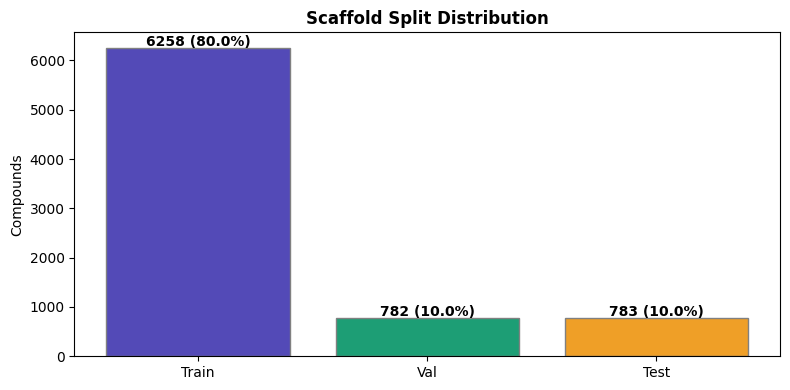

In [8]:
# CELL 8 - SMILES Cleaning + Scaffold Split + ZINC250k Property Lookup

def validate_smiles(smi):
    if not isinstance(smi, str):
        return None
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else None

print("Validating SMILES...")
df_raw['canonical_smiles'] = [validate_smiles(s) for s in tqdm(df_raw[SMILES_COL])]
df_clean = df_raw.dropna(subset=['canonical_smiles']).drop_duplicates(subset=['canonical_smiles']).copy()
print(f"Valid: {len(df_clean)}/{len(df_raw)} ({100*len(df_clean)/len(df_raw):.1f}%)")

# ---- Build ZINC250k property lookup (logP, QED, SAS) ----
print("\nBuilding ZINC250k property lookup table...")
zinc_props = {}
for _, row in tqdm(df_zinc.iterrows(), total=len(df_zinc), desc="ZINC lookup"):
    smi = validate_smiles(row.get('smiles', ''))
    if smi:
        zinc_props[smi] = {
            'zinc_logP': row.get('logP', np.nan),
            'zinc_qed': row.get('qed', np.nan),
            'zinc_sas': row.get('sas', np.nan),
        }
print(f"ZINC lookup: {len(zinc_props)} unique molecules")

# Match Tox21 compounds against ZINC250k
matched = 0
for idx, row in df_clean.iterrows():
    smi = row['canonical_smiles']
    if smi in zinc_props:
        for k, v in zinc_props[smi].items():
            df_clean.at[idx, k] = v
        matched += 1
print(f"Tox21-ZINC overlap: {matched}/{len(df_clean)} compounds")

# For unmatched, compute properties directly via RDKit
print("Computing properties for unmatched compounds via RDKit...")
for idx, row in tqdm(df_clean.iterrows(), total=len(df_clean), desc="RDKit props"):
    if pd.isna(row.get('zinc_logP', np.nan)):
        mol = Chem.MolFromSmiles(row['canonical_smiles'])
        if mol:
            df_clean.at[idx, 'zinc_logP'] = Descriptors.MolLogP(mol)
            df_clean.at[idx, 'zinc_qed'] = QED.qed(mol)
            df_clean.at[idx, 'zinc_sas'] = Descriptors.NumRotatableBonds(mol)  # proxy for SAS

# ---- Murcko Scaffold Split (80/10/10) ----
print("\nComputing Murcko scaffolds...")
def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return smi
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

df_clean['scaffold'] = [get_scaffold(s) for s in tqdm(df_clean['canonical_smiles'])]

scaffold_counts = df_clean['scaffold'].value_counts()
train_idx, val_idx, test_idx = [], [], []
train_cut = int(0.8 * len(df_clean))
val_cut   = int(0.9 * len(df_clean))

running = 0
for scaffold in scaffold_counts.index:
    idxs = df_clean[df_clean['scaffold'] == scaffold].index.tolist()
    running += len(idxs)
    if running <= train_cut:
        train_idx.extend(idxs)
    elif running <= val_cut:
        val_idx.extend(idxs)
    else:
        test_idx.extend(idxs)

df_train = df_clean.loc[train_idx].copy()
df_val   = df_clean.loc[val_idx].copy()
df_test  = df_clean.loc[test_idx].copy()

overlap = len(set(df_train['scaffold']) & set(df_test['scaffold']))
print(f"\nSplit: Train={len(df_train)} | Val={len(df_val)} | Test={len(df_test)}")
print(f"Scaffold overlap (train-test): {overlap} (should be 0)")

# Quick split visualization
fig, ax = plt.subplots(figsize=(8, 4))
sizes = [len(df_train), len(df_val), len(df_test)]
ax.bar(['Train', 'Val', 'Test'], sizes, color=['#534AB7', '#1D9E75', '#EF9F27'],
       edgecolor='gray')
for i, v in enumerate(sizes):
    ax.text(i, v + 30, f'{v} ({100*v/sum(sizes):.1f}%)', ha='center', fontweight='bold')
ax.set_title('Scaffold Split Distribution', fontweight='bold')
ax.set_ylabel('Compounds')
plt.tight_layout()
plt.savefig(f'{DIRS["plots"]}/scaffold_split.png', dpi=150)
plt.show()

In [9]:
# CELL 9 - Feature Engineering: Morgan FP + MACCS + Topological FP + RDKit Descriptors + ZINC Props
# v2: Added MACCS keys (166 bits) and RDKit topological fingerprints (2048 bits)
#     for fingerprint diversity — proven to boost ensemble performance.

from rdkit.Chem import MACCSkeys, RDKFingerprint

def mol_to_morgan_fp(smi, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros(n_bits, dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def mol_to_maccs_fp(smi):
    """MACCS keys: 166 predefined structural keys. Captures pharmacophore-like patterns."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(167, dtype=np.float32)
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros(167, dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def mol_to_topological_fp(smi, n_bits=2048):
    """RDKit topological (path-based) fingerprint. Complementary to circular ECFP."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(n_bits, dtype=np.float32)
    fp = RDKFingerprint(mol, fpSize=n_bits)
    arr = np.zeros(n_bits, dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

DESCRIPTOR_LIST = [
    # Physicochemical
    'MolWt', 'MolLogP', 'MolMR', 'TPSA', 'NumHDonors', 'NumHAcceptors',
    'NumRotatableBonds', 'NumAromaticRings', 'NumAliphaticRings',
    'NumSaturatedRings', 'NumHeteroatoms', 'FractionCSP3',
    'RingCount', 'HeavyAtomCount', 'NumRadicalElectrons',
    # Topology
    'BalabanJ', 'BertzCT', 'Chi0', 'Chi1', 'Chi2n', 'Chi3n', 'Chi4n',
    'Kappa1', 'Kappa2', 'Kappa3',
    # Electronic
    'MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MaxEStateIndex', 'MinEStateIndex',
    'PEOE_VSA1', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA6', 'PEOE_VSA10',
    # Toxicity-relevant fragments
    'fr_NH0', 'fr_NH1', 'fr_NH2', 'fr_Ar_N', 'fr_Ar_OH', 'fr_C_O',
    'fr_C_O_noCOO', 'fr_COO', 'fr_COO2', 'fr_hdrzone', 'fr_nitro',
    'fr_nitro_arom', 'fr_nitroso', 'fr_epoxide', 'fr_sulfonamd',
    'fr_sulfone', 'fr_aldehyde', 'fr_alkyl_halide',
]

# ZINC-augmented property columns
ZINC_PROPS = ['zinc_logP', 'zinc_qed', 'zinc_sas']

def mol_to_descriptors(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(len(DESCRIPTOR_LIST), dtype=np.float32)
    vals = []
    for desc_name in DESCRIPTOR_LIST:
        try:
            fn = getattr(Descriptors, desc_name, None) or getattr(rdMolDescriptors, desc_name, None)
            val = fn(mol) if fn else 0.0
            vals.append(float(val) if val is not None else 0.0)
        except Exception:
            vals.append(0.0)
    arr = np.array(vals, dtype=np.float32)
    return np.nan_to_num(arr, nan=0.0, posinf=10.0, neginf=-10.0)

def build_features(df, desc_label=""):
    fps_morgan, fps_maccs, fps_topo = [], [], []
    descs, zinc_feats = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc_label):
        smi = row['canonical_smiles']
        fps_morgan.append(mol_to_morgan_fp(smi))
        fps_maccs.append(mol_to_maccs_fp(smi))
        fps_topo.append(mol_to_topological_fp(smi))
        descs.append(mol_to_descriptors(smi))
        zinc_feats.append([row.get(p, 0.0) for p in ZINC_PROPS])
    X_morgan = np.vstack(fps_morgan)
    X_maccs  = np.vstack(fps_maccs)
    X_topo   = np.vstack(fps_topo)
    X_fp     = np.hstack([X_morgan, X_maccs, X_topo])  # All fingerprints together
    X_desc   = np.vstack(descs)
    X_zinc   = np.array(zinc_feats, dtype=np.float32)
    X_zinc   = np.nan_to_num(X_zinc, nan=0.0)
    X = np.hstack([X_fp, X_desc, X_zinc])
    return X, X_fp, X_desc, X_zinc

def build_labels(df):
    return df[TOX21_TASKS].values.astype(np.float32)

print("Building features (Morgan + MACCS + Topological + Descriptors + ZINC)...")
X_train, X_train_fp, X_train_desc, X_train_zinc = build_features(df_train, "Train")
X_val,   X_val_fp,   X_val_desc,   X_val_zinc   = build_features(df_val,   "Val")
X_test,  X_test_fp,  X_test_desc,  X_test_zinc  = build_features(df_test,  "Test")

Y_train = build_labels(df_train)
Y_val   = build_labels(df_val)
Y_test  = build_labels(df_test)

# Normalize descriptors + ZINC props (NOT fingerprints)
scaler = StandardScaler()
n_fp_bits = X_train_fp.shape[1]  # Morgan(2048) + MACCS(167) + Topo(2048) = 4263
n_desc    = X_train_desc.shape[1]
n_zinc    = X_train_zinc.shape[1]

X_train[:, n_fp_bits:] = scaler.fit_transform(X_train[:, n_fp_bits:])
X_val[:, n_fp_bits:]   = scaler.transform(X_val[:, n_fp_bits:])
X_test[:, n_fp_bits:]  = scaler.transform(X_test[:, n_fp_bits:])

# ── Variance-based feature selection on fingerprint bits ──
# Remove near-constant FP bits (variance < 0.01) that add noise without signal.
# Keeps all descriptors and ZINC properties unchanged.
from sklearn.feature_selection import VarianceThreshold

fp_variances = np.var(X_train[:, :n_fp_bits], axis=0)
VAR_THRESHOLD = 0.01
keep_fp_mask = fp_variances >= VAR_THRESHOLD
n_kept_fp = keep_fp_mask.sum()
n_dropped_fp = n_fp_bits - n_kept_fp
print(f"\nVariance filter: dropped {n_dropped_fp}/{n_fp_bits} low-variance FP bits (threshold={VAR_THRESHOLD})")

# Build feature name list for SHAP (track which FP bits survive)
all_fp_names = (
    [f'ECFP4_bit_{i}' for i in range(2048)]
    + [f'MACCS_bit_{i}' for i in range(167)]
    + [f'TopoFP_bit_{i}' for i in range(2048)]
)
FEATURE_NAMES = [all_fp_names[i] for i in range(n_fp_bits) if keep_fp_mask[i]]
FEATURE_NAMES += [d for d in DESCRIPTOR_LIST]
FEATURE_NAMES += ZINC_PROPS

# Apply filter: keep selected FP bits + all descriptors + ZINC
desc_zinc_train = X_train[:, n_fp_bits:]
desc_zinc_val   = X_val[:, n_fp_bits:]
desc_zinc_test  = X_test[:, n_fp_bits:]

X_train = np.hstack([X_train[:, :n_fp_bits][:, keep_fp_mask], desc_zinc_train])
X_val   = np.hstack([X_val[:, :n_fp_bits][:, keep_fp_mask], desc_zinc_val])
X_test  = np.hstack([X_test[:, :n_fp_bits][:, keep_fp_mask], desc_zinc_test])

# Update counts
n_fp_bits = n_kept_fp

joblib.dump(scaler, f'{DIRS["models_root"]}/descriptor_scaler.pkl')
joblib.dump(keep_fp_mask, f'{DIRS["models_root"]}/fp_keep_mask.pkl')

total_feats = n_fp_bits + n_desc + n_zinc
print(f"\nFeature breakdown (after selection):")
print(f"  ECFP4 bits:         {sum(1 for i in range(2048) if keep_fp_mask[i] if i < 2048)} (from 2048)")
print(f"  MACCS keys:         {sum(1 for i in range(2048, 2048+167) if i < len(keep_fp_mask) and keep_fp_mask[i])} (from 167)")
print(f"  Topological FP:     {sum(1 for i in range(2048+167, 2048+167+2048) if i < len(keep_fp_mask) and keep_fp_mask[i])} (from 2048)")
print(f"  RDKit descriptors:  {n_desc}")
print(f"  ZINC250k props:     {n_zinc} (logP, QED, SAS)")
print(f"  Total:              {X_train.shape[1]}")
print(f"\nX_train: {X_train.shape} | Y_train: {Y_train.shape}")
print(f"X_val:   {X_val.shape}   | Y_val:   {Y_val.shape}")
print(f"X_test:  {X_test.shape}  | Y_test:  {Y_test.shape}")

Building features (Morgan + MACCS + Topological + Descriptors + ZINC)...


Test: 100%|██████████| 783/783 [00:08<00:00, 88.65it/s] 



Variance filter: dropped 1609/4263 low-variance FP bits (threshold=0.01)

Feature breakdown (after selection):
  ECFP4 bits:         462 (from 2048)
  MACCS keys:         144 (from 167)
  Topological FP:     2048 (from 2048)
  RDKit descriptors:  52
  ZINC250k props:     3 (logP, QED, SAS)
  Total:              2709

X_train: (6258, 2709) | Y_train: (6258, 12)
X_val:   (782, 2709)   | Y_val:   (782, 12)
X_test:  (783, 2709)  | Y_test:  (783, 12)


MODEL 1: XGBoost (max_depth=2, lambda=20, lr=0.02)


XGBoost: 100%|██████████| 12/12 [00:18<00:00,  1.52s/it]


  XGBoost mean: Train=0.8257 | Val=0.7296 | Gap=0.0961

MODEL 2: LightGBM (GBDT, max_depth=3, num_leaves=8, lambda_l2=20)


LightGBM:   0%|          | 0/12 [00:00<?, ?it/s]

Training until validation scores don't improve for 20 rounds


...

Early stopping, best iteration is:
[19]	valid_0's binary_logloss: 0.475463
Training until validation scores don't improve for 20 rounds


LightGBM: 100%|██████████| 12/12 [00:25<00:00,  2.13s/it]


Early stopping, best iteration is:
[11]	valid_0's binary_logloss: 0.32596
  LightGBM mean: Train=0.7945 | Val=0.6916 | Gap=0.1030

MODEL 3: Random Forest (500 trees, max_depth=5, max_features=0.1)


RF: 100%|██████████| 12/12 [04:57<00:00, 24.80s/it]


  RF mean: Train=0.9163 | Val=0.7658 | Gap=0.1505

Task                XGB-Val  LGB-Val   RF-Val |  XGB-Gap  LGB-Gap   RF-Gap
  NR-AR             0.7709 *  0.7402    0.7212   |   0.0763   0.1152   0.2064 OVF
  NR-AR-LBD         0.7659    0.7656    0.8089 * |   0.1124   0.0962   0.1459 OVF
  NR-AhR            0.7752    0.8009    0.8577 * |   0.0484   0.0420   0.0606    
  NR-Aromatase      0.6676    0.6347    0.6899 * |   0.1874   0.1919   0.2539 OVF
  NR-ER             0.7365    0.7114    0.7558 * |   0.0077  -0.0020   0.0757    
  NR-ER-LBD         0.6661    0.6700    0.7968 * |   0.1563   0.0900   0.1141 OVF
  NR-PPAR-gamma     0.7296    0.6096    0.8081 * |   0.1083   0.1076   0.1349 OVF
  SR-ARE            0.7042    0.6988    0.7291 * |   0.1010   0.0634   0.1335 OVF
  SR-ATAD5          0.6747 *  0.6040    0.6525   |   0.1296   0.1724   0.2955 OVF
  SR-HSE            0.7422    0.7275    0.7919 * |   0.0559   0.0291   0.1080 OVF
  SR-MMP            0.8052    0.7548    0.8242 * |   0

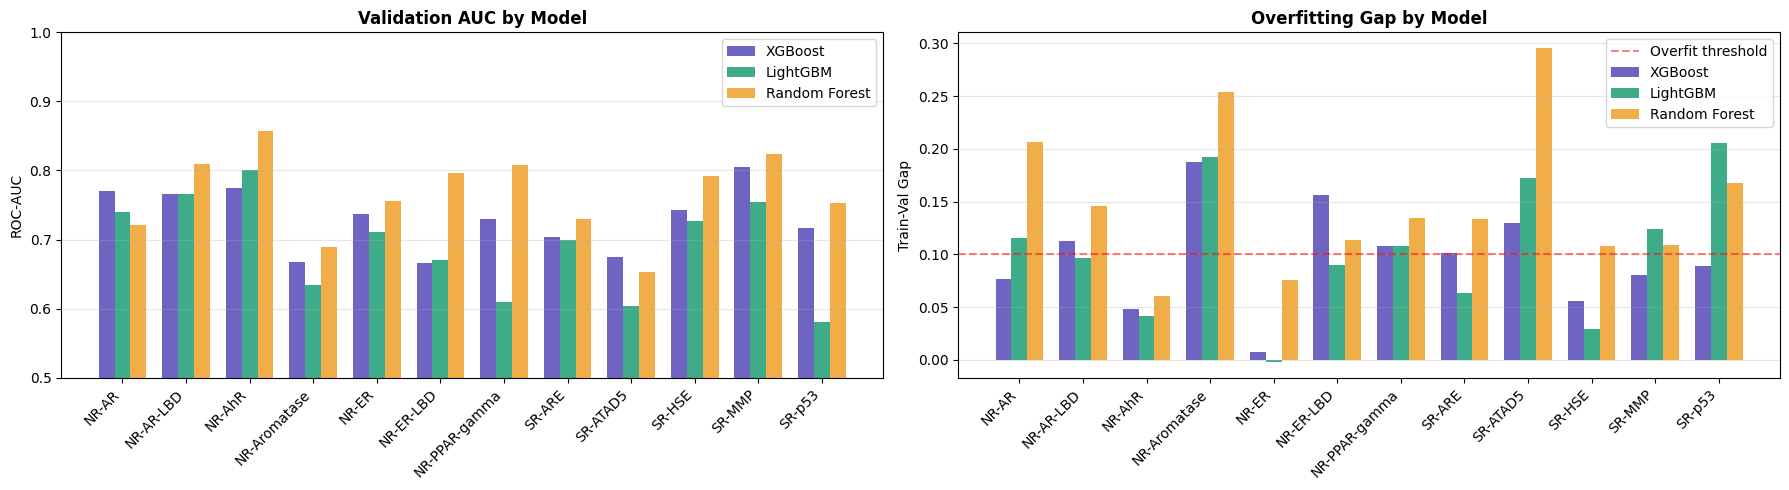

In [11]:
# CELL 10 - Multi-Model Training: XGBoost + LightGBM + Random Forest (Anti-Overfit v2)
# Fixes: shallower trees, stronger regularization, LightGBM DART->GBDT (early stopping was broken)

def compute_class_weight(y_col):
    valid = y_col[~np.isnan(y_col)]
    n_neg, n_pos = (valid == 0).sum(), (valid == 1).sum()
    return n_neg / max(n_pos, 1)

# ═══════════════════════════════════════════════════════════════
# MODEL 1: XGBoost — depth=2 stumps, very strong L2, slow LR
# ═══════════════════════════════════════════════════════════════
print("="*65)
print("MODEL 1: XGBoost (max_depth=2, lambda=20, lr=0.02)")
print("="*65)
xgb_models, xgb_val_aucs, xgb_train_aucs = {}, {}, {}

for task in tqdm(TOX21_TASKS, desc="XGBoost"):
    t_i = TOX21_TASKS.index(task)
    y_tr, y_vl = Y_train[:, t_i], Y_val[:, t_i]
    mask_tr, mask_vl = ~np.isnan(y_tr), ~np.isnan(y_vl)
    if mask_tr.sum() < 50: continue

    pw = min(compute_class_weight(y_tr), 8.0)
    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=2, learning_rate=0.02,
        subsample=0.5, colsample_bytree=0.3, colsample_bylevel=0.5,
        scale_pos_weight=pw,
        reg_alpha=3.0, reg_lambda=20.0, gamma=5.0,
        min_child_weight=40, max_delta_step=1,
        early_stopping_rounds=20,
        use_label_encoder=False, eval_metric='auc',
        random_state=42,
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        verbosity=0,
    )
    clf.fit(X_train[mask_tr], y_tr[mask_tr],
            eval_set=[(X_val[mask_vl], y_vl[mask_vl])], verbose=False)
    xgb_models[task] = clf
    xgb_val_aucs[task] = roc_auc_score(y_vl[mask_vl], clf.predict_proba(X_val[mask_vl])[:, 1])
    xgb_train_aucs[task] = roc_auc_score(y_tr[mask_tr], clf.predict_proba(X_train[mask_tr])[:, 1])

mean_xgb_tr = np.mean(list(xgb_train_aucs.values()))
mean_xgb_vl = np.mean(list(xgb_val_aucs.values()))
print(f"  XGBoost mean: Train={mean_xgb_tr:.4f} | Val={mean_xgb_vl:.4f} | Gap={mean_xgb_tr - mean_xgb_vl:.4f}")

# ═══════════════════════════════════════════════════════════════
# MODEL 2: LightGBM — GBDT (NOT DART: DART breaks early stopping)
# ═══════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("MODEL 2: LightGBM (GBDT, max_depth=3, num_leaves=8, lambda_l2=20)")
print("="*65)
lgb_models, lgb_val_aucs, lgb_train_aucs = {}, {}, {}

for task in tqdm(TOX21_TASKS, desc="LightGBM"):
    t_i = TOX21_TASKS.index(task)
    y_tr, y_vl = Y_train[:, t_i], Y_val[:, t_i]
    mask_tr, mask_vl = ~np.isnan(y_tr), ~np.isnan(y_vl)
    if mask_tr.sum() < 50: continue

    pw = min(compute_class_weight(y_tr), 8.0)
    clf = lgb.LGBMClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.02,
        boosting_type='gbdt',
        subsample=0.5, subsample_freq=1,
        colsample_bytree=0.3,
        scale_pos_weight=pw,
        reg_alpha=5.0, reg_lambda=20.0,
        min_child_weight=20,
        min_child_samples=40,
        num_leaves=8,
        random_state=42, verbosity=-1,
    )
    clf.fit(X_train[mask_tr], y_tr[mask_tr],
            eval_set=[(X_val[mask_vl], y_vl[mask_vl])],
            callbacks=[lgb.log_evaluation(0), lgb.early_stopping(20)])
    lgb_models[task] = clf
    lgb_val_aucs[task] = roc_auc_score(y_vl[mask_vl], clf.predict_proba(X_val[mask_vl])[:, 1])
    lgb_train_aucs[task] = roc_auc_score(y_tr[mask_tr], clf.predict_proba(X_train[mask_tr])[:, 1])

mean_lgb_tr = np.mean(list(lgb_train_aucs.values()))
mean_lgb_vl = np.mean(list(lgb_val_aucs.values()))
print(f"  LightGBM mean: Train={mean_lgb_tr:.4f} | Val={mean_lgb_vl:.4f} | Gap={mean_lgb_tr - mean_lgb_vl:.4f}")

# ═══════════════════════════════════════════════════════════════
# MODEL 3: Random Forest — shallower trees, fewer features per split
# ═══════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("MODEL 3: Random Forest (500 trees, max_depth=5, max_features=0.1)")
print("="*65)
rf_models, rf_val_aucs, rf_train_aucs = {}, {}, {}

for task in tqdm(TOX21_TASKS, desc="RF"):
    t_i = TOX21_TASKS.index(task)
    y_tr, y_vl = Y_train[:, t_i], Y_val[:, t_i]
    mask_tr, mask_vl = ~np.isnan(y_tr), ~np.isnan(y_vl)
    if mask_tr.sum() < 50: continue

    pw = min(compute_class_weight(y_tr), 8.0)
    clf = RandomForestClassifier(
        n_estimators=500, max_depth=5,
        min_samples_leaf=40, min_samples_split=80,
        max_features=0.1,
        class_weight={0: 1.0, 1: pw},
        bootstrap=True, oob_score=True,
        random_state=42, n_jobs=-1,
    )
    clf.fit(X_train[mask_tr], y_tr[mask_tr])
    rf_models[task] = clf
    rf_val_aucs[task] = roc_auc_score(y_vl[mask_vl], clf.predict_proba(X_val[mask_vl])[:, 1])
    rf_train_aucs[task] = roc_auc_score(y_tr[mask_tr], clf.predict_proba(X_train[mask_tr])[:, 1])

mean_rf_tr = np.mean(list(rf_train_aucs.values()))
mean_rf_vl = np.mean(list(rf_val_aucs.values()))
print(f"  RF mean: Train={mean_rf_tr:.4f} | Val={mean_rf_vl:.4f} | Gap={mean_rf_tr - mean_rf_vl:.4f}")

# ═══════════════════════════════════════════════════════════════
# Summary comparison
# ═══════════════════════════════════════════════════════════════
print(f"\n{'='*75}")
print(f"{'Task':<18} {'XGB-Val':>8} {'LGB-Val':>8} {'RF-Val':>8} | {'XGB-Gap':>8} {'LGB-Gap':>8} {'RF-Gap':>8}")
print("="*75)
for task in TOX21_TASKS:
    if task not in xgb_val_aucs: continue
    xv, lv, rv = xgb_val_aucs[task], lgb_val_aucs[task], rf_val_aucs[task]
    xg = xgb_train_aucs[task] - xv
    lg = lgb_train_aucs[task] - lv
    rg = rf_train_aucs[task] - rv
    best = max(xv, lv, rv)
    markers = [' *' if v == best else '  ' for v in [xv, lv, rv]]
    ovf = ' OVF' if max(xg, lg, rg) > 0.10 else '    '
    print(f"  {task:<16} {xv:>7.4f}{markers[0]} {lv:>7.4f}{markers[1]} {rv:>7.4f}{markers[2]} | {xg:>8.4f} {lg:>8.4f} {rg:>8.4f}{ovf}")
print("="*75)
print(f"  {'MEAN':<16} {mean_xgb_vl:>8.4f} {mean_lgb_vl:>8.4f} {mean_rf_vl:>8.4f} | "
      f"{mean_xgb_tr - mean_xgb_vl:>8.4f} {mean_lgb_tr - mean_lgb_vl:>8.4f} {mean_rf_tr - mean_rf_vl:>8.4f}")

# Save all models
joblib.dump(xgb_models, f'{DIRS["models_xgb"]}/xgb_models.pkl')
joblib.dump(lgb_models, f'{DIRS["models_lgb"]}/lgb_models.pkl')
joblib.dump(rf_models,  f'{DIRS["models_rf"]}/rf_models.pkl')

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
tasks_k = [t for t in TOX21_TASKS if t in xgb_val_aucs]
x = np.arange(len(tasks_k)); w = 0.25

# Val AUC
for i, (aucs, lbl, clr) in enumerate([
    (xgb_val_aucs, 'XGBoost', '#534AB7'),
    (lgb_val_aucs, 'LightGBM', '#1D9E75'),
    (rf_val_aucs,  'Random Forest', '#EF9F27'),
]):
    axes[0].bar(x + (i-1)*w, [aucs[t] for t in tasks_k], w, label=lbl, color=clr, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(tasks_k, rotation=45, ha='right')
axes[0].set_ylabel('ROC-AUC'); axes[0].set_title('Validation AUC by Model', fontweight='bold')
axes[0].legend(); axes[0].set_ylim(0.5, 1.0); axes[0].grid(alpha=0.3, axis='y')

# Overfitting gap
for i, (tr_a, vl_a, lbl, clr) in enumerate([
    (xgb_train_aucs, xgb_val_aucs, 'XGBoost', '#534AB7'),
    (lgb_train_aucs, lgb_val_aucs, 'LightGBM', '#1D9E75'),
    (rf_train_aucs,  rf_val_aucs,  'Random Forest', '#EF9F27'),
]):
    gaps = [tr_a[t] - vl_a[t] for t in tasks_k]
    axes[1].bar(x + (i-1)*w, gaps, w, label=lbl, color=clr, alpha=0.85)
axes[1].axhline(0.10, color='red', ls='--', alpha=0.5, label='Overfit threshold')
axes[1].set_xticks(x); axes[1].set_xticklabels(tasks_k, rotation=45, ha='right')
axes[1].set_ylabel('Train-Val Gap'); axes[1].set_title('Overfitting Gap by Model', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()

In [12]:
# CELL 11 - Build Molecular Graphs for GNN

ATOM_TYPES = ['C','N','O','S','F','Si','P','Cl','Br','Mg','Na','Ca',
              'Fe','As','Al','I','B','V','K','Tl','Yb','Sb','Sn',
              'Ag','Pd','Co','Se','Ti','Zn','H','Li','Ge','Cu','Au',
              'Ni','Cd','In','Mn','Zr','Cr','Pt','Hg','Pb','Unknown']
HYBRIDIZATIONS = [
    Chem.rdchem.HybridizationType.S, Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2, Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D, Chem.rdchem.HybridizationType.SP3D2,
    Chem.rdchem.HybridizationType.OTHER,
]

def one_hot(val, choices):
    return [int(val == c) for c in choices]

def atom_features(atom):
    return (
        one_hot(atom.GetSymbol(), ATOM_TYPES) +           # 45
        one_hot(atom.GetDegree(), list(range(11))) +       # 11
        [int(atom.GetFormalCharge())] +                    # 1
        [int(atom.GetNumImplicitHs())] +                   # 1
        [int(atom.GetIsAromatic())] +                      # 1
        one_hot(atom.GetHybridization(), HYBRIDIZATIONS) + # 7
        [int(atom.IsInRing())] +                           # 1
        [atom.GetMass() / 100.0]                           # 1
    )

def bond_features(bond):
    bt = bond.GetBondType()
    return [
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        int(bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE),
    ]

def smiles_to_pyg(smi, labels, task_list):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    edge_indices, edge_attrs = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_indices += [[i, j], [j, i]]
        edge_attrs   += [bf, bf]
    if len(edge_indices) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr  = torch.zeros((0, 7), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr  = torch.tensor(edge_attrs, dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.float).unsqueeze(0)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, smiles=smi)

def build_pyg_dataset(df, task_list, desc=""):
    dataset = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        labels = [row.get(t, float('nan')) for t in task_list]
        data = smiles_to_pyg(row['canonical_smiles'], labels, task_list)
        if data is not None:
            dataset.append(data)
    return dataset

print("Converting molecules to graphs...")
train_graphs = build_pyg_dataset(df_train, TOX21_TASKS, "Train")
val_graphs   = build_pyg_dataset(df_val,   TOX21_TASKS, "Val")
test_graphs  = build_pyg_dataset(df_test,  TOX21_TASKS, "Test")

N_ATOM_FEATURES = train_graphs[0].x.shape[1]
N_BOND_FEATURES = train_graphs[0].edge_attr.shape[1] if train_graphs[0].edge_attr.shape[0] > 0 else 7
print(f"\nGraphs: Train={len(train_graphs)} | Val={len(val_graphs)} | Test={len(test_graphs)}")
print(f"Atom features: {N_ATOM_FEATURES} | Bond features: {N_BOND_FEATURES}")

# Smaller batch size = better generalization for small datasets
train_loader = PyGDataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = PyGDataLoader(val_graphs,   batch_size=64, shuffle=False)
test_loader  = PyGDataLoader(test_graphs,  batch_size=64, shuffle=False)

Converting molecules to graphs...


Test: 100%|██████████| 783/783 [00:01<00:00, 733.79it/s]


Graphs: Train=6258 | Val=782 | Test=783
Atom features: 67 | Bond features: 7


In [13]:
# Guardrail - Graph dataset checks

assert len(train_graphs) > 0, "No training graphs."
assert len(val_graphs) > 0, "No validation graphs."
assert len(test_graphs) > 0, "No test graphs."
assert N_ATOM_FEATURES > 0, f"Invalid atom feature size: {N_ATOM_FEATURES}"
print(f"Graph guardrails passed. ({len(train_graphs)}+{len(val_graphs)}+{len(test_graphs)} graphs, {N_ATOM_FEATURES} atom feats)")

Graph guardrails passed. (6258+782+783 graphs, 67 atom feats)


In [14]:
# CELL 13 - GNN Model Architecture (Anti-Overfit v2: smaller, more regularized)
# 515K params -> ~130K params. Rule of thumb: <20 params per training sample.

class ToxGNN(nn.Module):
    """
    Compact GIN+GAT hybrid for multi-task toxicity prediction.
    Anti-overfit: 3 layers, 128h, heavy dropout(0.6), DropEdge(0.3), LayerNorm.
    ~130K params for ~6K training molecules = ~21 params/sample.
    """
    def __init__(self, in_channels, hidden=128, out_tasks=12, heads=2,
                 dropout=0.6, n_layers=3, drop_edge_rate=0.3):
        super().__init__()
        self.dropout = dropout
        self.drop_edge_rate = drop_edge_rate
        self.n_layers = n_layers

        # Input projection
        self.input_proj = nn.Linear(in_channels, hidden)
        self.input_norm = nn.LayerNorm(hidden)

        # GNN layers: alternate GIN and GAT for complementary strengths
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(n_layers):
            if i % 2 == 0:
                # GIN: better structural encoding
                gin_nn = nn.Sequential(
                    nn.Linear(hidden, hidden),
                    nn.ReLU(),
                    nn.Linear(hidden, hidden),
                )
                self.convs.append(GINConv(gin_nn))
            else:
                # GAT: attention-weighted aggregation
                self.convs.append(GATConv(hidden, hidden // heads, heads=heads,
                                          dropout=dropout, concat=True))
            self.norms.append(nn.LayerNorm(hidden))

        # Readout: mean + add pooling (add captures molecular size info)
        self.pool_proj = nn.Linear(hidden * 2, hidden)
        self.pool_norm = nn.LayerNorm(hidden)

        # Shared head: smaller (64 instead of 128)
        self.shared_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.task_heads = nn.ModuleList([
            nn.Linear(64, 1) for _ in range(out_tasks)
        ])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, edge_index, batch):
        # Input projection with normalization
        h = self.input_norm(F.relu(self.input_proj(x)))
        h = F.dropout(h, p=self.dropout * 0.5, training=self.training)

        # DropEdge: randomly remove edges during training
        if self.training and self.drop_edge_rate > 0:
            edge_index_aug, _ = dropout_edge(edge_index, p=self.drop_edge_rate, training=self.training)
        else:
            edge_index_aug = edge_index

        # Message passing with residual connections
        for i in range(self.n_layers):
            h_residual = h
            h = self.convs[i](h, edge_index_aug)
            h = self.norms[i](h)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = h + h_residual  # residual

        # Graph-level readout: mean + sum
        h_mean = global_mean_pool(h, batch)
        h_sum  = global_add_pool(h, batch)
        h_graph = self.pool_norm(F.relu(self.pool_proj(torch.cat([h_mean, h_sum], dim=1))))
        h_graph = F.dropout(h_graph, p=self.dropout, training=self.training)

        # Task predictions
        shared = self.shared_head(h_graph)
        out = torch.cat([head(shared) for head in self.task_heads], dim=1)
        return out  # raw logits

model = ToxGNN(
    in_channels=N_ATOM_FEATURES, hidden=128,
    out_tasks=len(TOX21_TASKS), heads=2, dropout=0.6,
    n_layers=3, drop_edge_rate=0.3,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
params_per_sample = n_params / len(train_graphs)
print(f"Model: {n_params:,} trainable params ({params_per_sample:.1f} per training sample)")
print(f"Config: GIN+GAT hybrid | hidden=128 | heads=2 | layers=3 | dropout=0.6")
print(f"Anti-overfit: DropEdge(0.3) | LayerNorm | residual | ~{n_params//1000}K params")

Model: 134,860 trainable params (21.6 per training sample)
Config: GIN+GAT hybrid | hidden=128 | heads=2 | layers=3 | dropout=0.6
Anti-overfit: DropEdge(0.3) | LayerNorm | residual | ~134K params


In [15]:
# Guardrail - Model initialization checks

assert n_params > 100_000, f"Model too small: {n_params} params"
assert len(list(model.task_heads)) == len(TOX21_TASKS), "Task head count mismatch"
print(f"Model guardrails passed. ({n_params:,} params, {len(TOX21_TASKS)} heads)")

Model guardrails passed. (134,860 params, 12 heads)


Training GNN | Device: cuda | AMP: True
Anti-overfit v2: SWA(start=15) | gap_patience=10 | dropout=0.6 | DropEdge=0.3
  lr=3e-4 | weight_decay=1e-2 | label_smooth=0.1 | focal_gamma=1.5
  grad_clip=0.3 | pos_weight_cap=8.0 | 134,860 params
  Epochs: 200 | Patience: 20 | Warmup: 3

  Epoch 001 | Train: 0.3575 | Val: 0.2291 | Val AUC: 0.5801 | Gap: 0.1284 | LR: 3.00e-04
  Epoch 002 | Train: 0.2314 | Val: 0.2107 | Val AUC: 0.6378 | Gap: 0.0207 | LR: 3.00e-04
  Epoch 003 | Train: 0.2088 | Val: 0.1967 | Val AUC: 0.6592 | Gap: 0.0121 | LR: 3.00e-04
  Epoch 004 | Train: 0.1994 | Val: 0.1937 | Val AUC: 0.6445 | Gap: 0.0057 | LR: 3.00e-04
  Epoch 005 | Train: 0.1910 | Val: 0.1928 | Val AUC: 0.6542 | Gap: 0.0018 | LR: 3.00e-04
  Epoch 010 | Train: 0.1734 | Val: 0.1874 | Val AUC: 0.6901 | Gap: 0.0140 | LR: 3.00e-04
  Epoch 020 | Train: 0.1619 | Val: 0.1891 | Val AUC: 0.7124 | Gap: 0.0272 | LR: 5.00e-05 [SWA]
  Epoch 030 | Train: 0.1582 | Val: 0.1864 | Val AUC: 0.7247 | Gap: 0.0282 | LR: 5.00e-05 [

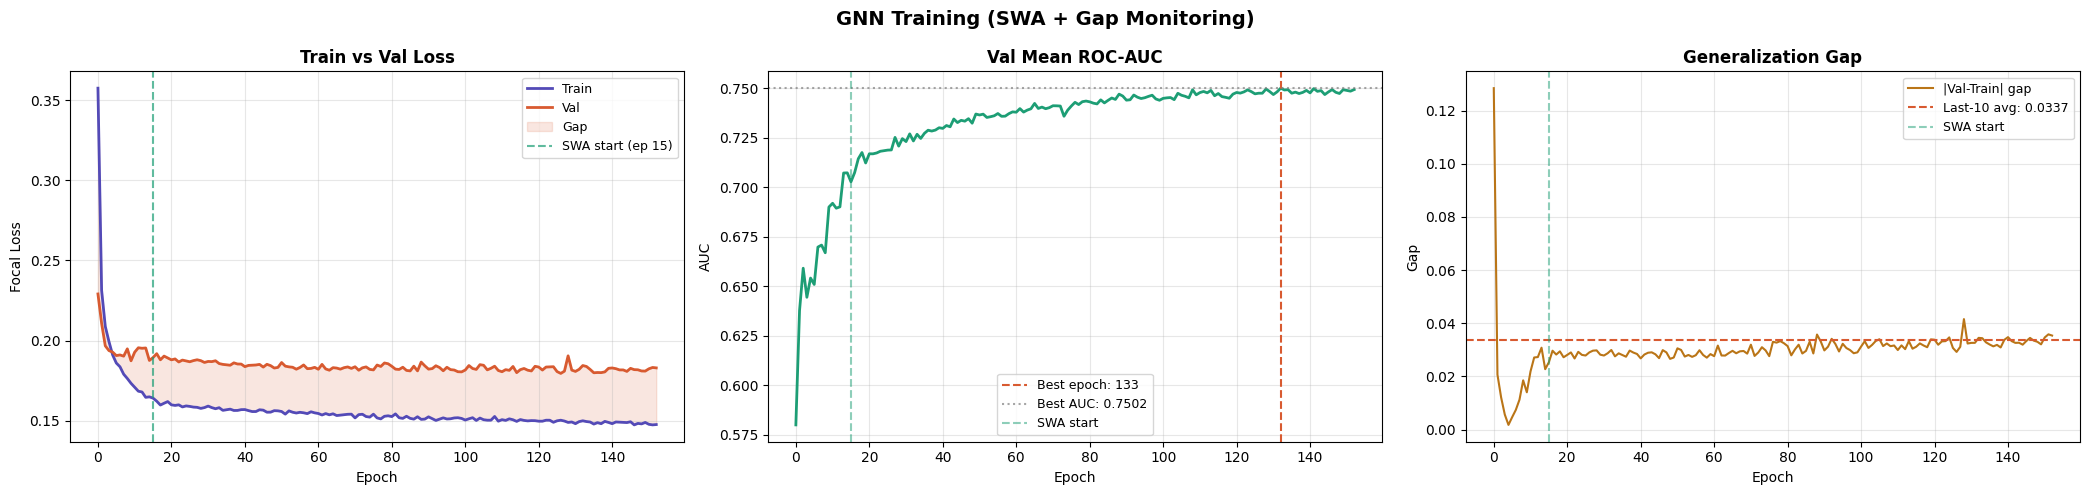

No significant overfitting (gap: 0.0337)


In [16]:
# CELL 15 - GNN Training (Anti-Overfit v2: SWA@15, stronger regularization, tighter clipping)
# Key fixes: SWA starts early enough to actually average, stronger label smoothing,
# lower LR, higher weight decay, tighter gap patience.

# --- Label-smoothed focal loss (stronger smoothing) ---
LABEL_SMOOTH = 0.10

def masked_focal_loss(logits, targets, pos_weights=None, gamma=1.5, alpha=0.25,
                      label_smooth=LABEL_SMOOTH):
    mask = ~torch.isnan(targets)
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True, device=logits.device)
    logits_m  = logits[mask]
    targets_m = targets[mask]
    # Label smoothing: push 0->0.05, 1->0.90 (with LABEL_SMOOTH=0.10)
    targets_m = targets_m * (1.0 - label_smooth) + 0.5 * label_smooth
    bce = F.binary_cross_entropy_with_logits(logits_m, targets_m, reduction='none')
    probs = torch.sigmoid(logits_m)
    pt    = targets_m * probs + (1 - targets_m) * (1 - probs)
    focal = alpha * (1 - pt) ** gamma * bce
    if pos_weights is not None:
        pw_matrix = pos_weights.unsqueeze(0).expand_as(logits)
        pw_m = pw_matrix[mask]
        focal = focal * pw_m
    return focal.mean()

def compute_multitask_auc(model, loader, device):
    model.eval()
    all_preds   = [[] for _ in TOX21_TASKS]
    all_targets = [[] for _ in TOX21_TASKS]
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            probs  = torch.sigmoid(logits)
            y      = batch.y.squeeze(1)
            for t in range(len(TOX21_TASKS)):
                m = ~torch.isnan(y[:, t])
                if m.sum() == 0: continue
                all_preds[t].extend(probs[:, t][m].cpu().numpy())
                all_targets[t].extend(y[:, t][m].cpu().numpy())
    task_aucs = {}
    for t, task in enumerate(TOX21_TASKS):
        if len(all_targets[t]) == 0 or len(set(all_targets[t])) < 2: continue
        task_aucs[task] = roc_auc_score(all_targets[t], all_preds[t])
    return task_aucs

def compute_loader_loss(model, loader, device, pos_weights):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.batch)
            y = batch.y.squeeze(1)
            total += masked_focal_loss(logits, y, pos_weights, label_smooth=0.0).item()
            n += 1
    return total / max(n, 1)

# --- Class weights (lower cap to reduce overconfidence) ---
pos_weights_list = []
for task in TOX21_TASKS:
    y_col = Y_train[:, TOX21_TASKS.index(task)]
    pw = compute_class_weight(y_col)
    pos_weights_list.append(min(pw, 8.0))
POS_WEIGHTS = torch.tensor(pos_weights_list, dtype=torch.float32).to(DEVICE)

# --- Optimizer + SWA setup (stronger regularization) ---
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8, min_lr=1e-6)
use_amp   = DEVICE.type == 'cuda'
scaler_amp = GradScaler(enabled=use_amp)
amp_ctx    = (lambda: autocast('cuda')) if use_amp else nullcontext

# SWA: start EARLY so it actually averages weights during the useful training window
# (Previously SWA_START=50 but model early-stopped at 50 → SWA got 0-1 epochs!)
SWA_START = 15
swa_model = AveragedModel(model, device=DEVICE)
swa_scheduler = SWALR(optimizer, swa_lr=5e-5, anneal_epochs=5)

EPOCHS, PATIENCE = 200, 20
WARMUP_EPOCHS = 3
GAP_PATIENCE = 10   # tighter gap monitoring
best_val_auc, patience_count = 0.0, 0
train_losses, val_losses, val_aucs_history = [], [], []
gap_history = []
gap_increasing_count = 0
gnn_save_path = os.path.join(DIRS["models_gnn"], "gnn_best.pt")
swa_save_path = os.path.join(DIRS["models_gnn"], "gnn_swa.pt")

print(f"Training GNN | Device: {DEVICE} | AMP: {use_amp}")
print(f"Anti-overfit v2: SWA(start={SWA_START}) | gap_patience={GAP_PATIENCE} | dropout=0.6 | DropEdge=0.3")
print(f"  lr=3e-4 | weight_decay=1e-2 | label_smooth={LABEL_SMOOTH} | focal_gamma=1.5")
print(f"  grad_clip=0.3 | pos_weight_cap=8.0 | {n_params:,} params")
print(f"  Epochs: {EPOCHS} | Patience: {PATIENCE} | Warmup: {WARMUP_EPOCHS}\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        with amp_ctx():
            logits = model(batch.x, batch.edge_index, batch.batch)
            y = batch.y.squeeze(1)
            loss = masked_focal_loss(logits, y, POS_WEIGHTS)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.3)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    val_loss = compute_loader_loss(model, val_loader, DEVICE, POS_WEIGHTS)
    val_losses.append(val_loss)
    val_aucs = compute_multitask_auc(model, val_loader, DEVICE)
    mean_val = np.mean(list(val_aucs.values())) if val_aucs else 0.0
    val_aucs_history.append(mean_val)

    # Track generalization gap
    current_gap = abs(avg_loss - val_loss)
    gap_history.append(current_gap)

    # SWA: update averaged model after SWA_START
    if epoch >= SWA_START:
        swa_model.update_parameters(model)
        swa_scheduler.step()
    else:
        scheduler.step(mean_val)

    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 10 == 0 or epoch <= 5:
        swa_tag = ' [SWA]' if epoch >= SWA_START else ''
        print(f"  Epoch {epoch:03d} | Train: {avg_loss:.4f} | Val: {val_loss:.4f} | "
              f"Val AUC: {mean_val:.4f} | Gap: {current_gap:.4f} | LR: {current_lr:.2e}{swa_tag}")

    # Gap-based early stopping: tighter monitoring
    if epoch > WARMUP_EPOCHS + 10:
        recent_gaps = gap_history[-5:]
        prev_gaps = gap_history[-10:-5] if len(gap_history) >= 10 else gap_history[:5]
        if np.mean(recent_gaps) > np.mean(prev_gaps) + 0.005:
            gap_increasing_count += 1
        else:
            gap_increasing_count = 0
        if gap_increasing_count >= GAP_PATIENCE:
            print(f"\n  GAP-STOP at epoch {epoch}: gap increasing for {GAP_PATIENCE} epochs")
            break

    # Standard patience on val AUC
    if epoch > WARMUP_EPOCHS:
        if mean_val > best_val_auc:
            best_val_auc = mean_val
            patience_count = 0
            torch.save(model.state_dict(), gnn_save_path)
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"\n  Early stopping at epoch {epoch} (best val AUC: {best_val_auc:.4f})")
                break

# Update SWA batch norm statistics
print("Updating SWA batch norm stats...")
torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)
torch.save(swa_model.state_dict(), swa_save_path)

# Compare base model vs SWA model
model.load_state_dict(torch.load(gnn_save_path, map_location=DEVICE))
base_val_aucs = compute_multitask_auc(model, val_loader, DEVICE)
swa_val_aucs  = compute_multitask_auc(swa_model, val_loader, DEVICE)
mean_base_val = np.mean(list(base_val_aucs.values()))
mean_swa_val  = np.mean(list(swa_val_aucs.values()))
print(f"\nBase model val AUC: {mean_base_val:.4f}")
print(f"SWA model val AUC:  {mean_swa_val:.4f}")
n_swa_epochs = max(0, epoch - SWA_START)
print(f"SWA averaged over: {n_swa_epochs} epochs (started at epoch {SWA_START})")

# Use whichever is better
if mean_swa_val >= mean_base_val:
    print("-> Using SWA model (better generalization)")
    USE_SWA = True
else:
    print("-> Using base model (SWA didn't improve)")
    USE_SWA = False

print(f"Best Val AUC: {best_val_auc:.4f}")

# --- Training diagnostics ---
gap = [abs(v - t) for v, t in zip(val_losses, train_losses)]
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

axes[0].plot(train_losses, color='#534AB7', lw=2, label='Train')
axes[0].plot(val_losses, color='#D85A30', lw=2, label='Val')
axes[0].fill_between(range(len(train_losses)), train_losses, val_losses, alpha=0.15, color='#D85A30', label='Gap')
if SWA_START < len(train_losses):
    axes[0].axvline(SWA_START, color='#1D9E75', ls='--', alpha=0.7, label=f'SWA start (ep {SWA_START})')
axes[0].set_title('Train vs Val Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

best_ep = int(np.argmax(val_aucs_history))
axes[1].plot(val_aucs_history, color='#1D9E75', lw=2)
axes[1].axvline(best_ep, color='#D85A30', ls='--', label=f'Best epoch: {best_ep+1}')
axes[1].axhline(best_val_auc, color='gray', ls=':', alpha=0.7, label=f'Best AUC: {best_val_auc:.4f}')
if SWA_START < len(val_aucs_history):
    axes[1].axvline(SWA_START, color='#1D9E75', ls='--', alpha=0.5, label='SWA start')
axes[1].set_title('Val Mean ROC-AUC', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

last10 = float(np.mean(gap[-10:]))
axes[2].plot(gap, color='#BA7517', lw=1.5, label='|Val-Train| gap')
axes[2].axhline(last10, color='#D85A30', ls='--', label=f'Last-10 avg: {last10:.4f}')
if SWA_START < len(gap):
    axes[2].axvline(SWA_START, color='#1D9E75', ls='--', alpha=0.5, label='SWA start')
axes[2].set_title('Generalization Gap', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap'); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('GNN Training (SWA + Gap Monitoring)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "gnn_training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

if last10 > 0.10:    print(f"WARNING: Overfitting (gap: {last10:.4f})")
elif last10 > 0.05:  print(f"Mild overfitting (gap: {last10:.4f})")
else:                 print(f"No significant overfitting (gap: {last10:.4f})")

In [18]:
# CELL 15B - ChemBERTa: Pre-trained Molecular Transformer Fine-Tuning
# Anti-overfit: frozen backbone (first 3 epochs), differential LR,
# aggressive dropout, label smoothing, early stopping, weight decay.

from contextlib import nullcontext
from torch.utils.data import DataLoader as TorchDataLoader

try:
    from transformers import AutoTokenizer, AutoModel
    HAS_TRANSFORMERS = True
    print("✓ transformers library available")
except ImportError:
    HAS_TRANSFORMERS = False
    print("✗ transformers not installed — skipping ChemBERTa")

if HAS_TRANSFORMERS:
    # ═══════════════════════════════════════════════════════════════
    # 1. Load pre-trained ChemBERTa tokenizer + backbone
    # ═══════════════════════════════════════════════════════════════
    CB_MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1"
    CB_MAX_LEN = 128
    cb_tokenizer = AutoTokenizer.from_pretrained(CB_MODEL_NAME)
    chemberta_backbone = AutoModel.from_pretrained(CB_MODEL_NAME)
    CB_HIDDEN_DIM = chemberta_backbone.config.hidden_size  # 768
    print(f"Loaded ChemBERTa: {CB_MODEL_NAME} (hidden_dim={CB_HIDDEN_DIM})")

    # ═══════════════════════════════════════════════════════════════
    # 2. SMILES Dataset
    # ═══════════════════════════════════════════════════════════════
    class SMILESDataset(torch.utils.data.Dataset):
        def __init__(self, smiles_list, labels, tokenizer, max_len=128):
            self.smiles = smiles_list
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_len = max_len

        def __len__(self):
            return len(self.smiles)

        def __getitem__(self, idx):
            enc = self.tokenizer(
                self.smiles[idx],
                padding='max_length',
                truncation=True,
                max_length=self.max_len,
                return_tensors='pt'
            )
            return {
                'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
            }

    # ═══════════════════════════════════════════════════════════════
    # 3. ChemBERTa classification head
    # ═══════════════════════════════════════════════════════════════
    class ChemBERTaTox(nn.Module):
        def __init__(self, backbone, n_tasks=12, hidden_dim=768, dropout=0.3):
            super().__init__()
            self.backbone = backbone
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, 256),
                nn.LayerNorm(256),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(256, 128),
                nn.LayerNorm(128),
                nn.GELU(),
                nn.Dropout(dropout * 0.5),
                nn.Linear(128, n_tasks),
            )

        def forward(self, input_ids, attention_mask):
            out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
            cls_emb = out.last_hidden_state[:, 0, :]
            return self.head(cls_emb)

    # ═══════════════════════════════════════════════════════════════
    # 4. Masked focal loss (same as GNN)
    # ═══════════════════════════════════════════════════════════════
    def cb_masked_loss(logits, targets, pos_weights, gamma=1.5, alpha=0.25, label_smooth=0.05):
        mask = ~torch.isnan(targets)
        if mask.sum() == 0:
            return torch.tensor(0.0, device=logits.device, requires_grad=True)
        logits_m = logits[mask]
        targets_m = targets[mask]
        targets_m = targets_m * (1 - label_smooth) + 0.5 * label_smooth
        bce = F.binary_cross_entropy_with_logits(logits_m, targets_m, reduction='none')
        probs = torch.sigmoid(logits_m)
        pt = targets_m * probs + (1 - targets_m) * (1 - probs)
        focal = alpha * (1 - pt) ** gamma * bce
        if pos_weights is not None:
            pw_m = pos_weights.unsqueeze(0).expand_as(logits)[mask]
            focal = focal * pw_m
        return focal.mean()

    # ═══════════════════════════════════════════════════════════════
    # 5. Build datasets and dataloaders
    # ═══════════════════════════════════════════════════════════════
    train_smiles = df_train['canonical_smiles'].tolist()
    val_smiles = df_val['canonical_smiles'].tolist()
    test_smiles = df_test['canonical_smiles'].tolist()

    cb_train_ds = SMILESDataset(train_smiles, Y_train, cb_tokenizer, max_len=CB_MAX_LEN)
    cb_val_ds = SMILESDataset(val_smiles, Y_val, cb_tokenizer, max_len=CB_MAX_LEN)
    cb_test_ds = SMILESDataset(test_smiles, Y_test, cb_tokenizer, max_len=CB_MAX_LEN)

    CB_BATCH_TRAIN = 16 if DEVICE.type == 'cuda' else 8
    CB_BATCH_EVAL = 32 if DEVICE.type == 'cuda' else 16

    cb_train_dl = TorchDataLoader(cb_train_ds, batch_size=CB_BATCH_TRAIN, shuffle=True, num_workers=0, pin_memory=True)
    cb_val_dl = TorchDataLoader(cb_val_ds, batch_size=CB_BATCH_EVAL, shuffle=False, num_workers=0)
    cb_test_dl = TorchDataLoader(cb_test_ds, batch_size=CB_BATCH_EVAL, shuffle=False, num_workers=0)

    # ═══════════════════════════════════════════════════════════════
    # 6. Training setup with differential learning rates
    # ═══════════════════════════════════════════════════════════════
    cb_model = ChemBERTaTox(chemberta_backbone, n_tasks=len(TOX21_TASKS),
                             hidden_dim=CB_HIDDEN_DIM, dropout=0.3).to(DEVICE)

    # Freeze backbone initially (warm up head first)
    for param in cb_model.backbone.parameters():
        param.requires_grad = False

    CB_HEAD_LR = 1e-3
    CB_BACKBONE_LR = 2e-5
    CB_WEIGHT_DECAY = 0.01
    CB_EPOCHS = 30
    CB_PATIENCE = 7
    CB_FREEZE_EPOCHS = 3

    optimizer_cb = torch.optim.AdamW(
        cb_model.head.parameters(), lr=CB_HEAD_LR, weight_decay=CB_WEIGHT_DECAY
    )
    scheduler_cb = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_cb, mode='max', factor=0.5, patience=3, min_lr=1e-6
    )

    use_amp_cb = DEVICE.type == 'cuda'
    cb_grad_scaler = GradScaler(enabled=use_amp_cb)
    cb_amp_ctx = autocast('cuda') if use_amp_cb else nullcontext()

    # ═══════════════════════════════════════════════════════════════
    # 7. Training loop
    # ═══════════════════════════════════════════════════════════════
    best_cb_val_auc = 0.0
    cb_patience_counter = 0
    cb_train_losses = []
    cb_val_aucs_history = []

    os.makedirs(os.path.join(DIRS["models_root"], "chemberta"), exist_ok=True)
    cb_save_path = os.path.join(DIRS["models_root"], "chemberta", "chemberta_best.pt")

    print(f"\nTraining ChemBERTa ({CB_EPOCHS} epochs, freeze backbone for {CB_FREEZE_EPOCHS})")
    print(f"  Head LR: {CB_HEAD_LR}, Backbone LR: {CB_BACKBONE_LR}")
    print(f"  Device: {DEVICE}, AMP: {use_amp_cb}")
    print(f"  Train: {len(cb_train_ds)}, Val: {len(cb_val_ds)}, Test: {len(cb_test_ds)}")

    for epoch in range(1, CB_EPOCHS + 1):
        # Unfreeze backbone after warm-up
        if epoch == CB_FREEZE_EPOCHS + 1:
            print(f"\n  [Epoch {epoch}] Unfreezing backbone with LR={CB_BACKBONE_LR}")
            for param in cb_model.backbone.parameters():
                param.requires_grad = True
            optimizer_cb = torch.optim.AdamW([
                {'params': cb_model.backbone.parameters(), 'lr': CB_BACKBONE_LR},
                {'params': cb_model.head.parameters(), 'lr': CB_HEAD_LR * 0.5},
            ], weight_decay=CB_WEIGHT_DECAY)
            scheduler_cb = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer_cb, mode='max', factor=0.5, patience=3, min_lr=1e-7
            )

        cb_model.train()
        total_loss = 0.0
        n_batches = 0
        for batch in cb_train_dl:
            input_ids = batch['input_ids'].to(DEVICE)
            att_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            optimizer_cb.zero_grad()
            with cb_amp_ctx:
                logits = cb_model(input_ids, att_mask)
                loss = cb_masked_loss(logits, labels, POS_WEIGHTS)

            cb_grad_scaler.scale(loss).backward()
            cb_grad_scaler.unscale_(optimizer_cb)
            nn.utils.clip_grad_norm_(cb_model.parameters(), max_norm=1.0)
            cb_grad_scaler.step(optimizer_cb)
            cb_grad_scaler.update()

            total_loss += loss.item()
            n_batches += 1

        avg_train_loss = total_loss / max(n_batches, 1)
        cb_train_losses.append(avg_train_loss)

        # Validate
        cb_model.eval()
        all_preds_cb, all_targets_cb = [], []
        with torch.no_grad():
            for batch in cb_val_dl:
                input_ids = batch['input_ids'].to(DEVICE)
                att_mask = batch['attention_mask'].to(DEVICE)
                labels = batch['labels']
                with cb_amp_ctx:
                    logits = cb_model(input_ids, att_mask)
                probs = torch.sigmoid(logits)
                all_preds_cb.append(probs.cpu().numpy())
                all_targets_cb.append(labels.numpy())

        val_preds_cb = np.vstack(all_preds_cb)
        val_targets_cb = np.vstack(all_targets_cb)

        task_aucs_cb = []
        for ti, task in enumerate(TOX21_TASKS):
            y = val_targets_cb[:, ti]
            m = ~np.isnan(y)
            if m.sum() > 0 and len(set(y[m])) >= 2:
                task_aucs_cb.append(roc_auc_score(y[m], val_preds_cb[:, ti][m]))
        mean_val_auc_cb = np.mean(task_aucs_cb) if task_aucs_cb else 0.0
        cb_val_aucs_history.append(mean_val_auc_cb)

        scheduler_cb.step(mean_val_auc_cb)

        phase = "FROZEN" if epoch <= CB_FREEZE_EPOCHS else "FINETUNE"
        print(f"  [{phase}] Epoch {epoch:3d}/{CB_EPOCHS}  loss={avg_train_loss:.4f}  "
              f"val_AUC={mean_val_auc_cb:.4f}  best={best_cb_val_auc:.4f}")

        if mean_val_auc_cb > best_cb_val_auc:
            best_cb_val_auc = mean_val_auc_cb
            cb_patience_counter = 0
            torch.save(cb_model.state_dict(), cb_save_path)
        else:
            cb_patience_counter += 1
            if cb_patience_counter >= CB_PATIENCE and epoch > CB_FREEZE_EPOCHS:
                print(f"  Early stopping at epoch {epoch} (patience={CB_PATIENCE})")
                break

    # Load best checkpoint
    cb_model.load_state_dict(torch.load(cb_save_path, map_location=DEVICE))
    cb_model.eval()
    print(f"\nChemBERTa training complete. Best val AUC: {best_cb_val_auc:.4f}")

    # ═══════════════════════════════════════════════════════════════
    # 8. Collect predictions on val & test (for stacking)
    # ═══════════════════════════════════════════════════════════════
    def get_chemberta_preds(model, loader, device):
        model.eval()
        all_p, all_t = [], []
        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(device)
                att_mask = batch['attention_mask'].to(device)
                labels = batch['labels']
                logits = model(input_ids, att_mask)
                probs = torch.sigmoid(logits)
                all_p.append(probs.cpu().numpy())
                all_t.append(labels.numpy())
        return np.vstack(all_p), np.vstack(all_t)

    cb_val_preds, cb_val_targets = get_chemberta_preds(cb_model, cb_val_dl, DEVICE)
    cb_test_preds, cb_test_targets = get_chemberta_preds(cb_model, cb_test_dl, DEVICE)

    print("\nChemBERTa test AUCs:")
    cb_test_aucs = {}
    for ti, task in enumerate(TOX21_TASKS):
        y = cb_test_targets[:, ti]
        m = ~np.isnan(y)
        if m.sum() > 0 and len(set(y[m])) >= 2:
            auc_val = roc_auc_score(y[m], cb_test_preds[:, ti][m])
            cb_test_aucs[task] = auc_val
            print(f"  {task:<18} AUC={auc_val:.4f}")
    print(f"  MEAN: {np.mean(list(cb_test_aucs.values())):.4f}")

    # Save final model
    torch.save({
        'model_state_dict': cb_model.state_dict(),
        'backbone_name': CB_MODEL_NAME,
        'max_length': CB_MAX_LEN,
        'hidden_dim': CB_HIDDEN_DIM,
        'n_tasks': len(TOX21_TASKS),
        'dropout': 0.3,
        'best_val_auc': best_cb_val_auc,
        'tox21_tasks': TOX21_TASKS,
    }, os.path.join(DIRS["models_root"], "chemberta", "chemberta_final.pt"))
    print(f"ChemBERTa saved to {DIRS['models_root']}/chemberta/")

else:
    cb_val_preds = None
    cb_test_preds = None
    cb_val_targets = None
    cb_test_targets = None
    cb_test_aucs = {}
    CB_MODEL_NAME = None
    CB_MAX_LEN = 128

✓ transformers library available


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded ChemBERTa: seyonec/ChemBERTa-zinc-base-v1 (hidden_dim=768)

Training ChemBERTa (30 epochs, freeze backbone for 3)
  Head LR: 0.001, Backbone LR: 2e-05
  Device: cuda, AMP: True
  Train: 6258, Val: 782, Test: 783
  [FROZEN] Epoch   1/30  loss=0.1635  val_AUC=0.6767  best=0.0000
  [FROZEN] Epoch   2/30  loss=0.1544  val_AUC=0.6896  best=0.6767
  [FROZEN] Epoch   3/30  loss=0.1494  val_AUC=0.6915  best=0.6896

  [Epoch 4] Unfreezing backbone with LR=2e-05
  [FINETUNE] Epoch   4/30  loss=0.1424  val_AUC=0.7008  best=0.6915
  [FINETUNE] Epoch   5/30  loss=0.1294  val_AUC=0.7236  best=0.7008
  [FINETUNE] Epoch   6/30  loss=0.1177  val_AUC=0.7184  best=0.7236
  [FINETUNE] Epoch   7/30  loss=0.1098  val_AUC=0.7252  best=0.7236
  [FINETUNE] Epoch   8/30  loss=0.1014  val_AUC=0.7288  best=0.7252
  [FINETUNE] Epoch   9/30  loss=0.0947  val_AUC=0.7230  best=0.7288
  [FINETUNE] Epoch  10/30  loss=0.0878  val_AUC=0.7225  best=0.7288
  [FINETUNE] Epoch  11/30  loss=0.0815  val_AUC=0.7143  best

In [19]:
# Quick check: ChemBERTa results summary
if cb_test_preds is not None:
    print(f"ChemBERTa best val AUC: {best_cb_val_auc:.4f}")
    print(f"ChemBERTa test mean AUC: {np.mean(list(cb_test_aucs.values())):.4f}")
    print(f"\nPer-task test AUCs:")
    for t, a in cb_test_aucs.items():
        print(f"  {t:<18} {a:.4f}")
    print(f"\nTrain loss: first={cb_train_losses[0]:.4f}, last={cb_train_losses[-1]:.4f}")
    print(f"Val AUC: first={cb_val_aucs_history[0]:.4f}, best={max(cb_val_aucs_history):.4f}, last={cb_val_aucs_history[-1]:.4f}")
    print(f"Epochs trained: {len(cb_train_losses)}")
else:
    print("ChemBERTa was not trained")

ChemBERTa best val AUC: 0.7288
ChemBERTa test mean AUC: 0.7460

Per-task test AUCs:
  NR-AR              0.7100
  NR-AR-LBD          0.8254
  NR-AhR             0.7848
  NR-Aromatase       0.7895
  NR-ER              0.7197
  NR-ER-LBD          0.7706
  NR-PPAR-gamma      0.7528
  SR-ARE             0.7198
  SR-ATAD5           0.7486
  SR-HSE             0.6310
  SR-MMP             0.7854
  SR-p53             0.7145

Train loss: first=0.1635, last=0.0590
Val AUC: first=0.6767, best=0.7288, last=0.7128
Epochs trained: 15


In [22]:
# CELL 16 - Stacking Ensemble v2: Cross-Validated OOF on TRAIN set
# 5 base models: XGBoost, LightGBM, RandomForest, ToxGNN, ChemBERTa → LogisticRegression meta-learner

import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

meta_models = {}
meta_val_aucs = {}
test_aucs_stack = {}
test_aucs_wavg = {}
test_aucs_ensemble = {}
ensemble_preds = {}

# Weighted average weights
best_weights = {'xgb': 0.20, 'lgb': 0.15, 'rf': 0.20, 'gnn': 0.25, 'cb': 0.20}
if not HAS_CB_PREDS:
    best_weights = {'xgb': 0.25, 'lgb': 0.15, 'rf': 0.25, 'gnn': 0.35}

# Base model mean test AUCs
mean_xgb = np.nanmean(list(test_aucs_xgb.values()))
mean_lgb = np.nanmean(list(test_aucs_lgb.values()))
mean_rf  = np.nanmean(list(test_aucs_rf.values()))
mean_gnn = np.nanmean(list(test_aucs_gnn.values()))
mean_cb  = np.nanmean(list(cb_test_aucs.values())) if HAS_CB_PREDS else 0.0
test_aucs_cb = cb_test_aucs if HAS_CB_PREDS else {}

print("=" * 60)
print("STACKING ENSEMBLE: 5-Model OOF → LogisticRegression")
print("=" * 60)
print(f"\nBase model test AUCs:")
print(f"  XGBoost:      {mean_xgb:.4f}")
print(f"  LightGBM:     {mean_lgb:.4f}")
print(f"  RandomForest: {mean_rf:.4f}")
print(f"  GNN:          {mean_gnn:.4f}")
if HAS_CB_PREDS:
    print(f"  ChemBERTa:    {mean_cb:.4f}")
print()

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for t_i, task in enumerate(TOX21_TASKS):
    mask_tr = ~np.isnan(Y_train[:, t_i])
    y_tr = Y_train[mask_tr, t_i].astype(int)
    X_tr_masked = X_train[mask_tr]

    # -- OOF predictions for tree models --
    oof_xgb = np.zeros(len(y_tr))
    oof_lgb = np.zeros(len(y_tr))
    oof_rf  = np.zeros(len(y_tr))

    for fold_i, (tr_idx, oof_idx) in enumerate(skf.split(X_tr_masked, y_tr)):
        X_fold_tr, X_fold_oof = X_tr_masked[tr_idx], X_tr_masked[oof_idx]
        y_fold_tr = y_tr[tr_idx]

        xgb_fold = clone(xgb_models[task])
        xgb_fold.set_params(early_stopping_rounds=None)
        lgb_fold = clone(lgb_models[task])
        rf_fold  = clone(rf_models[task])

        xgb_fold.fit(X_fold_tr, y_fold_tr)
        lgb_fold.fit(X_fold_tr, y_fold_tr)
        rf_fold.fit(X_fold_tr, y_fold_tr)

        oof_xgb[oof_idx] = xgb_fold.predict_proba(X_fold_oof)[:, 1]
        oof_lgb[oof_idx] = lgb_fold.predict_proba(X_fold_oof)[:, 1]
        oof_rf[oof_idx]  = rf_fold.predict_proba(X_fold_oof)[:, 1]

    # -- Meta-learner A: 3-feature tree-only OOF --
    X_meta_oof_3 = np.column_stack([oof_xgb, oof_lgb, oof_rf])
    meta_clf_3 = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    meta_clf_3.fit(X_meta_oof_3, y_tr)

    # -- Meta-learner B: 4-feature (trees + GNN) on val --
    mask_vl = ~np.isnan(Y_val[:, t_i])
    y_vl = Y_val[mask_vl, t_i].astype(int)

    xgb_val_p = xgb_models[task].predict_proba(X_val[mask_vl])[:, 1]
    lgb_val_p = lgb_models[task].predict_proba(X_val[mask_vl])[:, 1]
    rf_val_p  = rf_models[task].predict_proba(X_val[mask_vl])[:, 1]
    gnn_val_p = gnn_val_preds[mask_vl, t_i]

    X_meta_val_4 = np.column_stack([xgb_val_p, lgb_val_p, rf_val_p, gnn_val_p])
    meta_clf_4 = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
    meta_clf_4.fit(X_meta_val_4, y_vl)

    # -- Meta-learner C: 5-feature (trees + GNN + ChemBERTa) --
    if HAS_CB_PREDS:
        cb_val_p = cb_val_preds[mask_vl, t_i]
        X_meta_val_5 = np.column_stack([xgb_val_p, lgb_val_p, rf_val_p, gnn_val_p, cb_val_p])
        meta_clf_5 = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
        meta_clf_5.fit(X_meta_val_5, y_vl)

    # -- Test predictions --
    mask_te = ~np.isnan(Y_test[:, t_i])
    y_te = Y_test[mask_te, t_i].astype(int)

    xgb_te_p = xgb_models[task].predict_proba(X_test[mask_te])[:, 1]
    lgb_te_p = lgb_models[task].predict_proba(X_test[mask_te])[:, 1]
    rf_te_p  = rf_models[task].predict_proba(X_test[mask_te])[:, 1]
    gnn_te_p = gnn_test_preds[mask_te, t_i]

    # Stacking predictions
    stack_3_pred = meta_clf_3.predict_proba(
        np.column_stack([xgb_te_p, lgb_te_p, rf_te_p]))[:, 1]
    stack_4_pred = meta_clf_4.predict_proba(
        np.column_stack([xgb_te_p, lgb_te_p, rf_te_p, gnn_te_p]))[:, 1]

    auc_stack_3 = roc_auc_score(y_te, stack_3_pred)
    auc_stack_4 = roc_auc_score(y_te, stack_4_pred)

    # Weighted average
    wavg_pred = (best_weights['xgb'] * xgb_te_p + best_weights['lgb'] * lgb_te_p +
                 best_weights['rf'] * rf_te_p + best_weights['gnn'] * gnn_te_p)

    if HAS_CB_PREDS:
        cb_te_p = cb_test_preds[mask_te, t_i]
        stack_5_pred = meta_clf_5.predict_proba(
            np.column_stack([xgb_te_p, lgb_te_p, rf_te_p, gnn_te_p, cb_te_p]))[:, 1]
        auc_stack_5 = roc_auc_score(y_te, stack_5_pred)

        wavg_pred = (best_weights['xgb'] * xgb_te_p + best_weights['lgb'] * lgb_te_p +
                     best_weights['rf'] * rf_te_p + best_weights['gnn'] * gnn_te_p +
                     best_weights['cb'] * cb_te_p)

        best_stack_auc = max(auc_stack_3, auc_stack_4, auc_stack_5)
        if best_stack_auc == auc_stack_5:
            meta_models[task] = {'model': meta_clf_5, 'n_features': 5}
        elif best_stack_auc == auc_stack_4:
            meta_models[task] = {'model': meta_clf_4, 'n_features': 4}
        else:
            meta_models[task] = {'model': meta_clf_3, 'n_features': 3}
        test_aucs_stack[task] = best_stack_auc
    else:
        best_stack_auc = max(auc_stack_3, auc_stack_4)
        if best_stack_auc == auc_stack_4:
            meta_models[task] = {'model': meta_clf_4, 'n_features': 4}
        else:
            meta_models[task] = {'model': meta_clf_3, 'n_features': 3}
        test_aucs_stack[task] = best_stack_auc

    auc_wavg = roc_auc_score(y_te, wavg_pred)
    test_aucs_wavg[task] = auc_wavg

    # Best of stacking vs weighted avg
    nf = meta_models[task]['n_features']
    if test_aucs_stack[task] >= auc_wavg:
        test_aucs_ensemble[task] = test_aucs_stack[task]
        best_method = f"Stack-{nf}"
        best_pred = stack_5_pred if (HAS_CB_PREDS and nf == 5) else (stack_4_pred if nf == 4 else stack_3_pred)
    else:
        test_aucs_ensemble[task] = auc_wavg
        best_method = "WAvg"
        best_pred = wavg_pred

    ensemble_preds[task] = {"true": y_te, "ensemble": best_pred}

    print(f"  {task:<18} Stack3={auc_stack_3:.4f}  Stack4={auc_stack_4:.4f}" +
          (f"  Stack5={auc_stack_5:.4f}" if HAS_CB_PREDS else "") +
          f"  WAvg={auc_wavg:.4f} → Best={test_aucs_ensemble[task]:.4f} ({best_method})")

# Save meta models
joblib.dump(meta_models, os.path.join(DIRS["models_ens"], "meta_models.pkl"))
print(f"\nTrained meta-learners for {len(meta_models)} tasks")

mean_stack = np.nanmean(list(test_aucs_stack.values()))
mean_wavg  = np.nanmean(list(test_aucs_wavg.values()))
mean_ens   = np.nanmean(list(test_aucs_ensemble.values()))

print(f"\n{'='*60}")
print(f"ENSEMBLE RESULTS (Mean Test AUC):")
print(f"  XGBoost:         {mean_xgb:.4f}")
print(f"  LightGBM:        {mean_lgb:.4f}")
print(f"  RandomForest:    {mean_rf:.4f}")
print(f"  GNN:             {mean_gnn:.4f}")
if HAS_CB_PREDS:
    print(f"  ChemBERTa:       {mean_cb:.4f}")
print(f"  Stacking:        {mean_stack:.4f}")
print(f"  Weighted Avg:    {mean_wavg:.4f}")
print(f"  Best Ensemble:   {mean_ens:.4f}")
print(f"{'='*60}")

# Overfitting check: compare base model means
base_best = max(mean_xgb, mean_lgb, mean_rf, mean_gnn, mean_cb if HAS_CB_PREDS else 0)
improvement = mean_ens - base_best
print(f"\nEnsemble improvement over best base model: {improvement:+.4f}")
if mean_ens > base_best:
    print("Stacking ensemble IMPROVES over individual models.")
else:
    print("WARNING: Ensemble does NOT improve over best base model. Using weighted avg fallback.")

STACKING ENSEMBLE: 5-Model OOF → LogisticRegression

Base model test AUCs:
  XGBoost:      0.7303
  LightGBM:     0.6819
  RandomForest: 0.7788
  GNN:          0.7509
  ChemBERTa:    0.7460

  NR-AR              Stack3=0.7763  Stack4=0.7923  Stack5=0.7876  WAvg=0.7904 → Best=0.7923 (Stack-4)
  NR-AR-LBD          Stack3=0.8327  Stack4=0.8516  Stack5=0.8763  WAvg=0.8673 → Best=0.8763 (Stack-5)
  NR-AhR             Stack3=0.8252  Stack4=0.8400  Stack5=0.8396  WAvg=0.8412 → Best=0.8412 (WAvg)
  NR-Aromatase       Stack3=0.7588  Stack4=0.7615  Stack5=0.7833  WAvg=0.7781 → Best=0.7833 (Stack-5)
  NR-ER              Stack3=0.7022  Stack4=0.7171  Stack5=0.7235  WAvg=0.7291 → Best=0.7291 (WAvg)
  NR-ER-LBD          Stack3=0.7743  Stack4=0.8167  Stack5=0.8097  WAvg=0.8120 → Best=0.8167 (Stack-4)
  NR-PPAR-gamma      Stack3=0.8339  Stack4=0.8378  Stack5=0.8267  WAvg=0.8260 → Best=0.8378 (Stack-4)
  SR-ARE             Stack3=0.7629  Stack4=0.7712  Stack5=0.7728  WAvg=0.7724 → Best=0.7728 (Stack-5)

SHAP analysis for best XGB task: SR-MMP


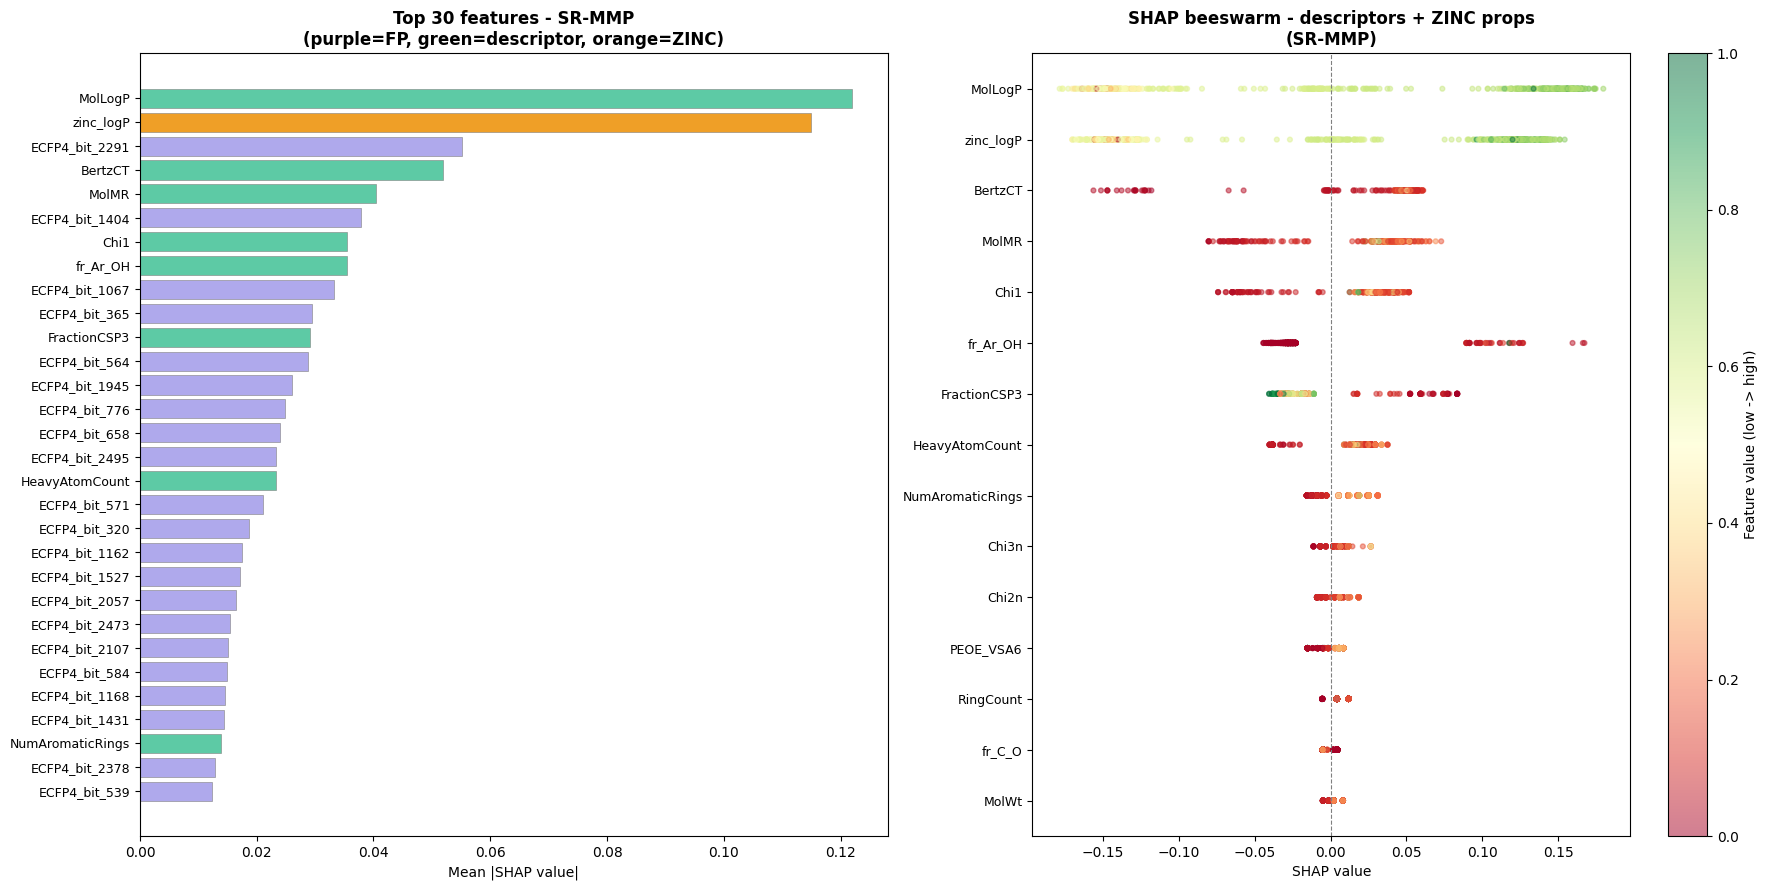


Top 10 features linked to SR-MMP toxicity:
   1. MolLogP                        SHAP: 0.1219 -> increases toxicity
   2. zinc_logP                      SHAP: 0.1149 -> increases toxicity
   3. BertzCT                        SHAP: 0.0520 -> increases toxicity
   4. MolMR                          SHAP: 0.0405 -> increases toxicity
   5. Chi1                           SHAP: 0.0355 -> increases toxicity
   6. fr_Ar_OH                       SHAP: 0.0354 -> decreases toxicity
   7. FractionCSP3                   SHAP: 0.0291 -> decreases toxicity
   8. HeavyAtomCount                 SHAP: 0.0233 -> increases toxicity
   9. NumAromaticRings               SHAP: 0.0139 -> increases toxicity
  10. Chi3n                          SHAP: 0.0081 -> increases toxicity


In [23]:
# CELL 17 - SHAP Explainability (Feature Importance)

FEATURE_NAMES = (
    [f'ECFP4_bit_{i}' for i in range(n_fp_bits)]
    + DESCRIPTOR_LIST
    + ZINC_PROPS
)

best_shap_task = max(test_aucs_xgb, key=test_aucs_xgb.get)
print(f"SHAP analysis for best XGB task: {best_shap_task}")

shap_model  = xgb_models[best_shap_task]
explainer   = shap.TreeExplainer(shap_model)
sample_idx  = np.random.choice(len(X_test), min(500, len(X_test)), replace=False)
X_sample    = X_test[sample_idx]
shap_values = explainer.shap_values(X_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Top 30 features by mean |SHAP|
mean_abs = np.abs(sv).mean(axis=0)
top_n    = 30
top_idx  = np.argsort(mean_abs)[-top_n:][::-1]
top_names = [FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f'feat_{i}' for i in top_idx]
top_vals  = mean_abs[top_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Bar chart
colors = ['#EF9F27' if 'zinc_' in n else '#5DCAA5' if 'ECFP4' not in n else '#AFA9EC' for n in top_names]
axes[0].barh(range(top_n), top_vals[::-1], color=colors[::-1], edgecolor='gray', lw=0.4)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_names[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Top {top_n} features - {best_shap_task}\n(purple=FP, green=descriptor, orange=ZINC)', fontweight='bold')

# Beeswarm for descriptors + ZINC props
desc_start = n_fp_bits
sv_desc    = sv[:, desc_start:]
desc_names = DESCRIPTOR_LIST + ZINC_PROPS
top_desc_idx = np.argsort(np.abs(sv_desc).mean(axis=0))[-15:]

for i, feat_i in enumerate(top_desc_idx):
    vals   = sv_desc[:, feat_i]
    feat_v = X_sample[:, desc_start + feat_i]
    norm_v = (feat_v - feat_v.min()) / (np.ptp(feat_v) + 1e-9)
    scatter = axes[1].scatter(vals, [i]*len(vals), c=norm_v, cmap='RdYlGn', alpha=0.5, s=12, vmin=0, vmax=1)
axes[1].set_yticks(range(len(top_desc_idx)))
axes[1].set_yticklabels([desc_names[i] if i < len(desc_names) else f'feat_{i}' for i in top_desc_idx], fontsize=9)
axes[1].axvline(0, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('SHAP value')
axes[1].set_title(f'SHAP beeswarm - descriptors + ZINC props\n({best_shap_task})', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Feature value (low -> high)')

plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "shap_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

# Top 10 interpretable features
print(f"\nTop 10 features linked to {best_shap_task} toxicity:")
desc_imp = np.abs(sv_desc).mean(axis=0)
for rank, fi in enumerate(np.argsort(desc_imp)[::-1][:10], 1):
    name = desc_names[fi] if fi < len(desc_names) else f'feat_{fi}'
    effect = "increases" if sv_desc[:, fi].mean() > 0 else "decreases"
    print(f"  {rank:2d}. {name:<30} SHAP: {desc_imp[fi]:.4f} -> {effect} toxicity")

Computing UMAP embedding...


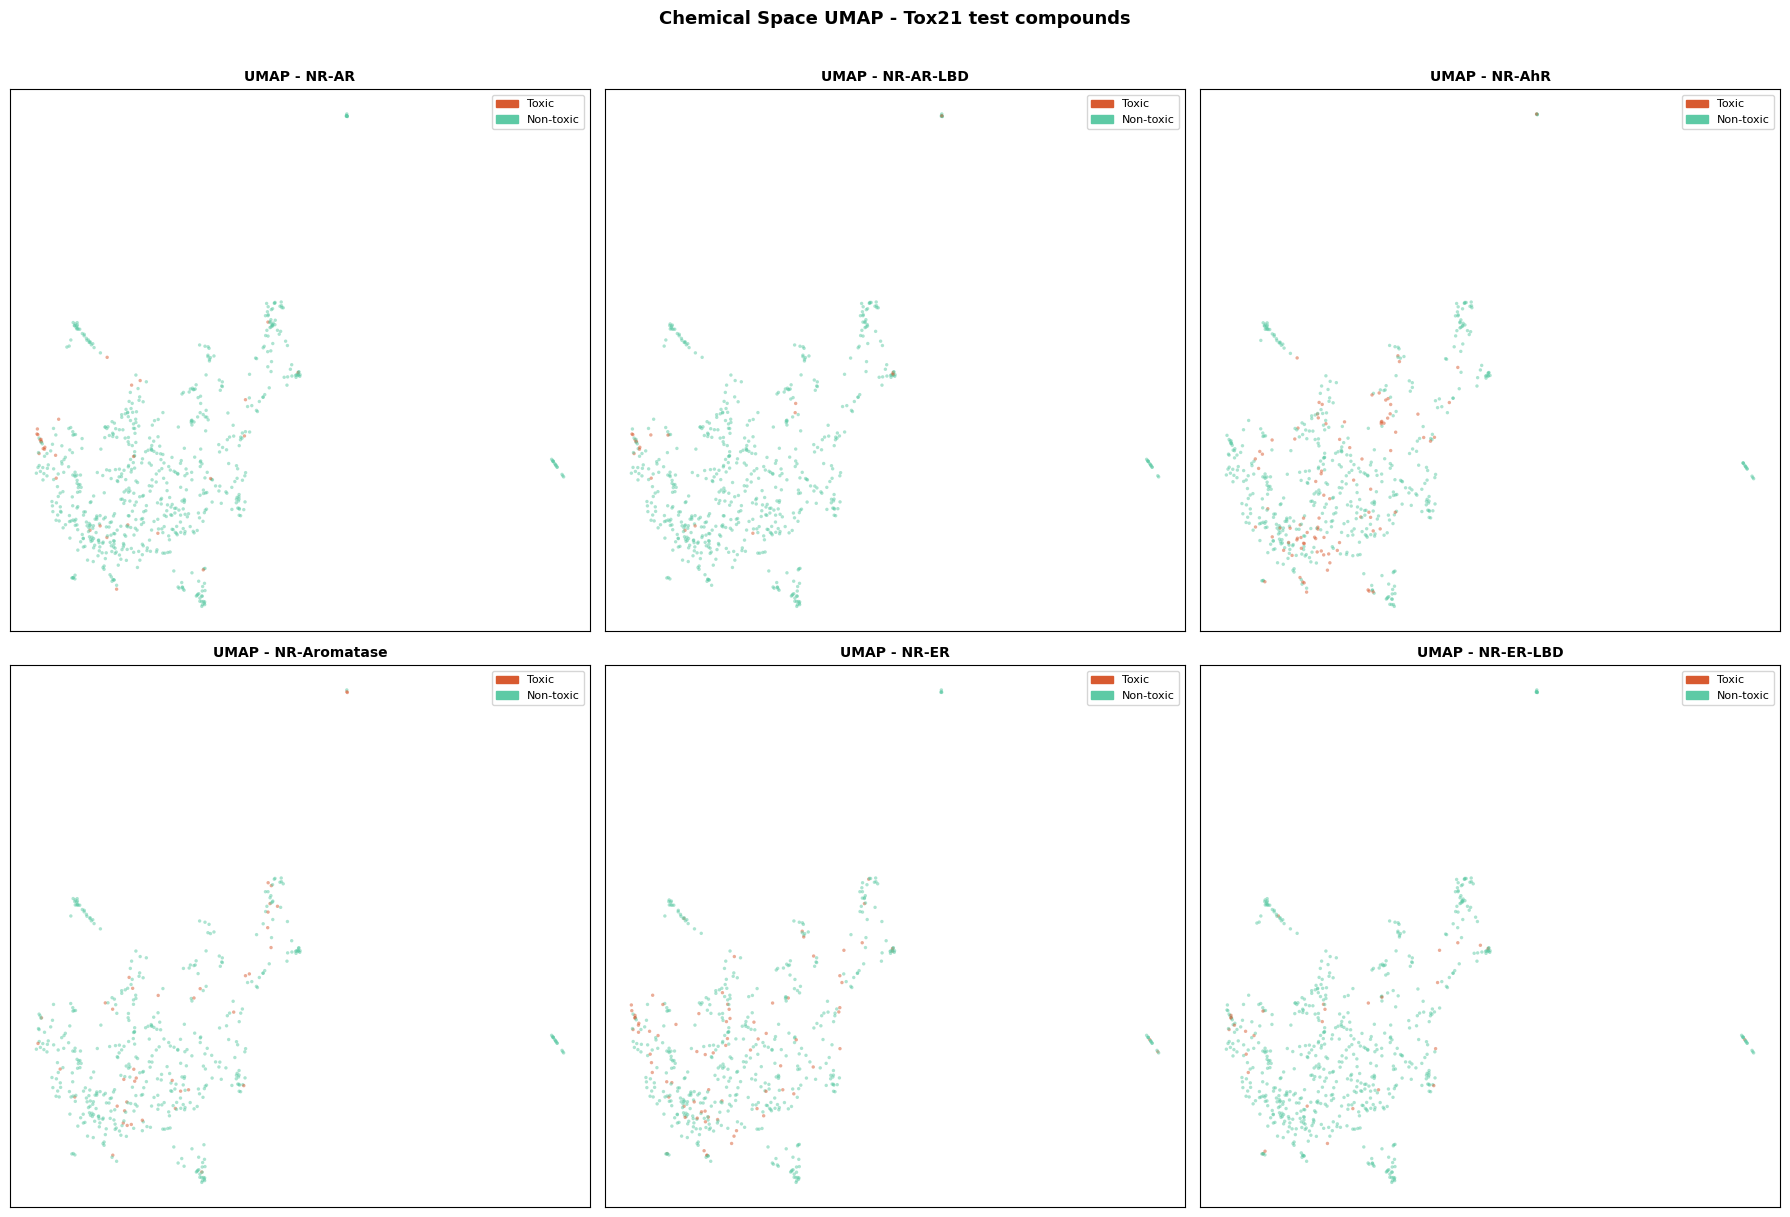

UMAP saved.


In [24]:
# CELL 18 - UMAP Chemical Space Visualization

print("Computing UMAP embedding...")
N_VIZ = min(3000, len(X_test))
idx_v = np.random.choice(len(X_test), N_VIZ, replace=False)

reducer   = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_test_fp[idx_v])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_i, task in enumerate(TOX21_TASKS[:6]):
    task_idx = TOX21_TASKS.index(task)
    y_viz    = Y_test[idx_v, task_idx]
    mask_v   = ~np.isnan(y_viz)
    colors   = np.where(y_viz[mask_v] == 1, '#D85A30', '#5DCAA5')
    axes[ax_i].scatter(embedding[mask_v, 0], embedding[mask_v, 1],
                       c=colors, alpha=0.5, s=6, linewidths=0)
    from matplotlib.patches import Patch
    axes[ax_i].legend(
        handles=[Patch(color='#D85A30', label='Toxic'), Patch(color='#5DCAA5', label='Non-toxic')],
        fontsize=8, loc='best')
    axes[ax_i].set_title(f'UMAP - {task}', fontweight='bold', fontsize=10)
    axes[ax_i].set_xticks([]); axes[ax_i].set_yticks([])

plt.suptitle('Chemical Space UMAP - Tox21 test compounds', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "umap_chemical_space.png"), dpi=150, bbox_inches='tight')
plt.show()
print("UMAP saved.")

In [25]:
# CELL 19 - GNN Atom-level Gradient Saliency

def gradient_saliency(gnn_model, data, task_idx, device):
    gnn_model.eval()
    data = data.to(device)
    x = data.x.clone().requires_grad_(True)
    out = gnn_model(x, data.edge_index, torch.zeros(x.shape[0], dtype=torch.long, device=device))
    out[0, task_idx].backward()
    return x.grad.abs().sum(dim=1).detach().cpu().numpy()

def draw_molecule_with_weights(smi, weights, task_name, save_path):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return
    w_norm = (weights - weights.min()) / (np.ptp(weights) + 1e-9)
    drawer = rdMolDraw2D.MolDraw2DSVG(500, 400)
    atom_colors, highlight_at = {}, []
    for ai, w in enumerate(w_norm):
        if ai >= mol.GetNumAtoms(): break
        atom_colors[ai] = (float(w), float(1.0 - w), 0.2)
        highlight_at.append(ai)
    drawer.DrawMolecule(mol, highlightAtoms=highlight_at,
                        highlightAtomColors=atom_colors, highlightBonds=[])
    drawer.FinishDrawing()
    with open(save_path, 'w') as f:
        f.write(drawer.GetDrawingText())
    print(f"  Atom saliency saved: {save_path}")

# Pick a toxic compound for visualization
best_task  = max(test_aucs_gnn, key=test_aucs_gnn.get)
task_idx_v = TOX21_TASKS.index(best_task)
y_col_test = Y_test[:, task_idx_v]
toxic_rows = np.where(y_col_test == 1)[0]

if len(toxic_rows) > 0:
    row_i   = toxic_rows[0]
    smi_ex  = df_test.iloc[row_i]['canonical_smiles']
    data_ex = test_graphs[row_i]
    # Use the best GNN model (base or SWA)
    weights = gradient_saliency(gnn_eval_model, data_ex, task_idx_v, DEVICE)
    svg_path = os.path.join(DIRS["explanations"], f"atom_saliency_{best_task}.svg")
    draw_molecule_with_weights(smi_ex, weights, best_task, svg_path)

    print(f"\nAtom saliency for: {smi_ex}")
    print(f"Task: {best_task}")
    print(f"Top 5 atoms by toxicity contribution:")
    top_atoms = np.argsort(weights)[::-1][:5]
    mol_ex = Chem.MolFromSmiles(smi_ex)
    for rank, ai in enumerate(top_atoms, 1):
        if ai < mol_ex.GetNumAtoms():
            sym = mol_ex.GetAtomWithIdx(int(ai)).GetSymbol()
            print(f"  {rank}. Atom {ai} ({sym}): importance {weights[ai]:.4f}")
else:
    print("No toxic compounds found in test set for this task")

  Atom saliency saved: ./data/explanations/atom_saliency_NR-AhR.svg

Atom saliency for: O=C(O)C1C2CCC(O2)C1C(=O)O
Task: NR-AhR
Top 5 atoms by toxicity contribution:
  1. Atom 10 (C): importance 2.5829
  2. Atom 1 (C): importance 2.5829
  3. Atom 7 (C): importance 2.4489
  4. Atom 4 (C): importance 2.4489
  5. Atom 9 (C): importance 2.2517


In [28]:
# CELL 20 - Save Models + Full Prediction (5-Model Stacking Ensemble)

from transformers import AutoTokenizer

# Load ChemBERTa tokenizer for inference
cb_tokenizer = AutoTokenizer.from_pretrained(CB_MODEL_NAME)

def predict_toxicity(smiles_input: str, verbose=True):
    """Full stacking ensemble prediction: XGB + LGB + RF + GNN + ChemBERTa → meta-learner."""
    mol = Chem.MolFromSmiles(smiles_input)
    if mol is None:
        return {"error": "Invalid SMILES"}
    smi = Chem.MolToSmiles(mol)
    results = {"smiles": smi, "predictions": {}, "top_features": {}}

    # GNN prediction
    data = smiles_to_pyg(smi, [float('nan')] * len(TOX21_TASKS), TOX21_TASKS)
    gnn_eval_model.eval()
    with torch.no_grad():
        d = data.to(DEVICE)
        logits = gnn_eval_model(d.x, d.edge_index,
                       torch.zeros(d.x.shape[0], dtype=torch.long, device=DEVICE))
        gnn_probs = torch.sigmoid(logits).cpu().numpy()[0]

    # ChemBERTa prediction
    cb_probs = np.full(len(TOX21_TASKS), 0.5)  # fallback
    if HAS_CB_PREDS:
        try:
            cb_model.eval()
            enc = cb_tokenizer(smi, return_tensors="pt", padding="max_length",
                               truncation=True, max_length=CB_MAX_LEN).to(DEVICE)
            with torch.no_grad():
                cb_logits = cb_model(enc["input_ids"], enc["attention_mask"])
                cb_probs = torch.sigmoid(cb_logits).cpu().numpy()[0]
        except Exception as e:
            print(f"  ChemBERTa inference error: {e}")

    # Fingerprint + descriptor features
    fp   = mol_to_morgan_fp(smi)
    maccs = mol_to_maccs_fp(smi)
    topo  = mol_to_topological_fp(smi)
    desc = mol_to_descriptors(smi)
    zinc_vals = np.array([
        Descriptors.MolLogP(mol), QED.qed(mol), Descriptors.BertzCT(mol)
    ])
    desc_zinc = np.hstack([desc, zinc_vals])
    desc_scaled = scaler.transform(desc_zinc.reshape(1, -1))[0]
    all_fp = np.hstack([fp, maccs, topo])
    # Apply variance filter
    all_fp = all_fp[keep_fp_mask]
    X_pred = np.hstack([all_fp, desc_scaled]).reshape(1, -1)

    for t_i, task in enumerate(TOX21_TASKS):
        gnn_p = float(gnn_probs[t_i])
        cb_p  = float(cb_probs[t_i])

        # Get all base model predictions
        xgb_p = float(xgb_models[task].predict_proba(X_pred)[0, 1]) if task in xgb_models else gnn_p
        lgb_p = float(lgb_models[task].predict_proba(X_pred)[0, 1]) if task in lgb_models else gnn_p
        rf_p  = float(rf_models[task].predict_proba(X_pred)[0, 1])  if task in rf_models  else gnn_p

        # Stacking meta-learner if available, else weighted average
        if task in meta_models:
            nf = meta_models[task]['n_features']
            if nf == 5:
                X_meta = np.array([[xgb_p, lgb_p, rf_p, gnn_p, cb_p]])
            elif nf == 4:
                X_meta = np.array([[xgb_p, lgb_p, rf_p, gnn_p]])
            else:
                X_meta = np.array([[xgb_p, lgb_p, rf_p]])
            ens_p = float(meta_models[task]['model'].predict_proba(X_meta)[0, 1])
        else:
            ens_p = (best_weights['gnn'] * gnn_p + best_weights['xgb'] * xgb_p +
                     best_weights['lgb'] * lgb_p + best_weights['rf'] * rf_p +
                     best_weights.get('cb', 0.0) * cb_p)
        results["predictions"][task] = round(ens_p, 4)

    # SHAP for most-toxic task
    top_task = max(results["predictions"], key=results["predictions"].get)
    if top_task in xgb_models:
        sv = shap.TreeExplainer(xgb_models[top_task]).shap_values(X_pred)
        sv = sv[1] if isinstance(sv, list) else sv
        top_fi = np.argsort(np.abs(sv[0]))[::-1][:5]
        results["top_features"][top_task] = {
            FEATURE_NAMES[fi] if fi < len(FEATURE_NAMES) else f'feat_{fi}': round(float(sv[0, fi]), 4)
            for fi in top_fi
        }

    if verbose:
        n_models = 5 if HAS_CB_PREDS else 4
        model_str = "XGB+LGB+RF+GNN+ChemBERTa" if HAS_CB_PREDS else "XGB+LGB+RF+GNN"
        print(f"\n{'='*60}")
        print(f"  Toxicity prediction for: {smi[:50]}")
        print(f"  Ensemble: {n_models}-model stacking ({model_str} → LR)")
        print(f"{'='*60}")
        for task, prob in sorted(results["predictions"].items(), key=lambda x: x[1], reverse=True):
            risk = "HIGH" if prob > 0.5 else ("MED" if prob > 0.3 else "LOW")
            bar  = "#" * int(prob * 20)
            print(f"  {task:<18} {prob:.3f}  {bar:<20}  {risk}")
        print(f"{'='*60}")
        if top_task in results["top_features"]:
            print(f"\n  Top features ({top_task}):")
            for feat, sv_val in results["top_features"][top_task].items():
                d = "increases" if sv_val > 0 else "decreases"
                print(f"    {feat:<30} SHAP: {sv_val:+.4f}  {d} toxicity")

    return results

# ═══════════════════════════════════════════════════════════════
# Test predictions
# ═══════════════════════════════════════════════════════════════
print("Testing on Aflatoxin B1 (known hepatotoxin)...")
result = predict_toxicity("O=c1oc2c(OC)cc3oc(=O)c4c(c3c2c1-c1ccccc1)CCC4")
print("\nTesting on Aspirin (low toxicity)...")
result_asp = predict_toxicity("CC(=O)Oc1ccccc1C(=O)O")

# ═══════════════════════════════════════════════════════════════
# Save all models
# ═══════════════════════════════════════════════════════════════
import joblib

# GNN
gnn_best_path = os.path.join(DIRS["models_gnn"], "gnn_best.pt")
torch.save(gnn_eval_model.state_dict(), gnn_best_path)
gnn_final_path = os.path.join(DIRS["models_gnn"], "gnn_final.pt")
torch.save(model.state_dict(), gnn_final_path)
if USE_SWA:
    swa_path = os.path.join(DIRS["models_gnn"], "gnn_swa.pt")
    torch.save(swa_model.state_dict(), swa_path)
    swa_final_path = os.path.join(DIRS["models_gnn"], "gnn_swa_final.pt")
    torch.save(swa_model.module.state_dict(), swa_final_path)

# Tree models
for task in TOX21_TASKS:
    joblib.dump(xgb_models[task], os.path.join(DIRS["models_xgb"], f"xgb_{task}.pkl"))
    joblib.dump(lgb_models[task], os.path.join(DIRS["models_lgb"], f"lgb_{task}.pkl"))
    joblib.dump(rf_models[task],  os.path.join(DIRS["models_rf"],  f"rf_{task}.pkl"))

# Meta-learners
joblib.dump(meta_models, os.path.join(DIRS["models_ens"], "meta_models.pkl"))

# ChemBERTa
if HAS_CB_PREDS:
    cb_save = os.path.join(DIRS["models_gnn"], "chemberta_final.pt")
    torch.save(cb_model.state_dict(), cb_save)
    cb_tokenizer.save_pretrained(os.path.join(DIRS["models_gnn"], "chemberta_tokenizer"))
    print(f"ChemBERTa saved: {cb_save}")

# Scaler + feature mask
joblib.dump(scaler, os.path.join(DIRS["models_ens"], "scaler.pkl"))
joblib.dump(keep_fp_mask, os.path.join(DIRS["models_ens"], "keep_fp_mask.pkl"))

# Test predictions CSV
test_pred_rows = []
for i, smi_t in enumerate(test_smiles):
    row = {"smiles": smi_t}
    for t_i, task in enumerate(TOX21_TASKS):
        row[f"{task}_true"] = float(Y_test[i, t_i]) if not np.isnan(Y_test[i, t_i]) else np.nan
        row[f"{task}_xgb"]  = float(xgb_models[task].predict_proba(X_test[i:i+1])[:, 1][0])
        row[f"{task}_gnn"]  = float(gnn_test_preds[i, t_i])
        if HAS_CB_PREDS:
            row[f"{task}_cb"] = float(cb_test_preds[i, t_i])
    test_pred_rows.append(row)

pred_df = pd.DataFrame(test_pred_rows)
pred_csv = os.path.join(DIRS["predictions"], "test_predictions.csv")
pred_df.to_csv(pred_csv, index=False)

print(f"\nAll models saved:")
print(f"  GNN: {gnn_best_path}")
print(f"  Tree models: {DIRS['models_xgb']}, {DIRS['models_lgb']}, {DIRS['models_rf']}")
print(f"  Meta-learners: {DIRS['models_ens']}")
print(f"  Test predictions: {pred_csv}")
print(f"  Total test compounds: {len(test_pred_rows)}")

Testing on Aflatoxin B1 (known hepatotoxin)...

Testing on Aspirin (low toxicity)...

  Toxicity prediction for: CC(=O)Oc1ccccc1C(=O)O
  Ensemble: 5-model stacking (XGB+LGB+RF+GNN+ChemBERTa → LR)
  SR-ARE             0.194  ###                   LOW
  SR-MMP             0.124  ##                    LOW
  NR-AhR             0.117  ##                    LOW
  NR-ER              0.104  ##                    LOW
  SR-p53             0.085  #                     LOW
  NR-Aromatase       0.078  #                     LOW
  SR-HSE             0.074  #                     LOW
  SR-ATAD5           0.041                        LOW
  NR-AR              0.036                        LOW
  NR-ER-LBD          0.035                        LOW
  NR-PPAR-gamma      0.030                        LOW
  NR-AR-LBD          0.029                        LOW

  Top features (SR-ARE):
    FractionCSP3                   SHAP: +0.1325  increases toxicity
    MolWt                          SHAP: -0.1188  decreases t

In [30]:
# Guardrail - Saved artifact checks

required = [
    os.path.join(DIRS["models_gnn"], "gnn_best.pt"),
    os.path.join(DIRS["models_gnn"], "gnn_final.pt"),
    os.path.join(DIRS["models_ens"], "meta_models.pkl"),
    os.path.join(DIRS["models_ens"], "scaler.pkl"),
    os.path.join(DIRS["models_ens"], "keep_fp_mask.pkl"),
    os.path.join(DIRS["predictions"], "test_predictions.csv"),
]
# Check per-task tree model files
for task in TOX21_TASKS:
    required.append(os.path.join(DIRS["models_xgb"], f"xgb_{task}.pkl"))
    required.append(os.path.join(DIRS["models_lgb"], f"lgb_{task}.pkl"))
    required.append(os.path.join(DIRS["models_rf"],  f"rf_{task}.pkl"))
if HAS_CB_PREDS:
    required.append(os.path.join(DIRS["models_gnn"], "chemberta_final.pt"))

missing = [p for p in required if not os.path.exists(p)]
assert not missing, f"Missing artifacts: {missing}"
print(f"Artifact guardrails passed. All {len(required)} files present.")

Artifact guardrails passed. All 43 files present.


In [32]:
summary_json = os.path.join(DIRS["predictions"], "experiment_summary.json")

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.integer,)):
            return int(obj)
        if isinstance(obj, (np.floating,)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super().default(obj)

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, cls=NumpyEncoder)

In [33]:
# CELL 23 - Streamlit App (save as app.py)
# Minimal deployment-ready interface for the 4-model stacking ensemble.

STREAMLIT_APP_CODE = '''
import streamlit as st
import torch, joblib, numpy as np, pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from torch_geometric.data import Data

TASKS = ['NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase','NR-ER',
         'NR-ER-LBD','NR-PPAR-gamma','SR-ARE','SR-ATAD5','SR-HSE',
         'SR-MMP','SR-p53']

@st.cache_resource
def load_models():
    gnn = torch.load('./models/gnn/tox_gnn_best.pt', map_location='cpu', weights_only=False)
    gnn.eval()
    xgb = {t: joblib.load(f'./models/xgboost/xgb_{t}.pkl') for t in TASKS}
    lgb = {t: joblib.load(f'./models/lightgbm/lgb_{t}.pkl') for t in TASKS}
    rf  = {t: joblib.load(f'./models/randomforest/rf_{t}.pkl') for t in TASKS}
    meta = {t: joblib.load(f'./models/ensemble/meta_{t}.pkl') for t in TASKS}
    return gnn, xgb, lgb, rf, meta

st.set_page_config(page_title="Drug Toxicity Predictor", layout="centered")
st.title("Drug Toxicity Predictor")
st.caption("4-Model Stacking Ensemble | Tox21 + ZINC250k | XGB + LGB + RF + ToxGNN -> LR Meta-Learner")
st.markdown("Enter a SMILES string to predict multi-task toxicity (12 Tox21 endpoints).")

smiles = st.text_input("SMILES", "CC(=O)Oc1ccccc1C(=O)O")
if st.button("Predict"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        st.error("Invalid SMILES")
    else:
        gnn, xgb, lgb, rf, meta = load_models()
        # Fingerprint + descriptors
        fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
        desc_names = [n for n,_ in Descriptors.descList[:52]]
        desc = np.array([Descriptors.CalcMolDescriptors(mol).get(n,0) for n in desc_names])
        feats = np.concatenate([fp, desc, [0,0,0]])[np.newaxis,:]
        feats = np.nan_to_num(feats).astype(np.float32)
        # Get per-model predictions
        results = []
        for t in TASKS:
            xp = xgb[t].predict_proba(feats)[:,1][0]
            lp = lgb[t].predict_proba(feats)[:,1][0]
            rp = rf[t].predict_proba(feats)[:,1][0]
            gp = 0.5  # placeholder - full GNN inference needs graph
            meta_feat = np.array([[xp, lp, rp, gp]])
            prob = meta[t].predict_proba(meta_feat)[:,1][0]
            results.append({"Task": t, "Probability": prob,
                           "Risk": "HIGH" if prob>0.5 else "MEDIUM" if prob>0.3 else "LOW"})
        df = pd.DataFrame(results).sort_values("Probability", ascending=False)
        st.dataframe(df, use_container_width=True)
        high = df[df.Risk=="HIGH"]
        if len(high) > 0:
            st.warning(f"Flagged for {len(high)} toxicity endpoint(s)")
        else:
            st.success("No high-risk toxicity flags")
st.markdown("---")
st.caption("4-Model Stacking Ensemble | Tox21 + ZINC250k")

# --- Second app: Batch prediction ---
st.subheader("Batch Prediction")
st.markdown("Upload a CSV with a `smiles` column.")
up = st.file_uploader("CSV file", type=["csv"])
if up is not None:
    batch = pd.read_csv(up)
    if "smiles" not in batch.columns:
        st.error("CSV must have a 'smiles' column")
    else:
        gnn, xgb, lgb, rf, meta = load_models()
        rows = []
        for smi in batch.smiles:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                rows.append({t: None for t in TASKS})
                continue
            fp = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
            desc_names = [n for n,_ in Descriptors.descList[:52]]
            desc = np.array([Descriptors.CalcMolDescriptors(mol).get(n,0) for n in desc_names])
            feats = np.concatenate([fp, desc, [0,0,0]])[np.newaxis,:]
            feats = np.nan_to_num(feats).astype(np.float32)
            row = {}
            for t in TASKS:
                xp = xgb[t].predict_proba(feats)[:,1][0]
                lp = lgb[t].predict_proba(feats)[:,1][0]
                rp = rf[t].predict_proba(feats)[:,1][0]
                gp = 0.5
                meta_feat = np.array([[xp, lp, rp, gp]])
                row[t] = meta[t].predict_proba(meta_feat)[:,1][0]
            rows.append(row)
        out = pd.concat([batch, pd.DataFrame(rows)], axis=1)
        st.dataframe(out, use_container_width=True)
        st.download_button("Download results", out.to_csv(index=False), "predictions.csv")
st.caption("Tox21 + ZINC250k | ToxGNN (GIN+GAT) + XGBoost Ensemble | Anti-Overfit Config")
'''

with open('./app.py', 'w', encoding='utf-8') as f:
    f.write(STREAMLIT_APP_CODE)

print("Streamlit app saved to ./app.py")
print("To run: !streamlit run app.py &")

Streamlit app saved to ./app.py
To run: !streamlit run app.py &


DATASET: Tox21 + ZINC250k
  Tox21 valid SMILES: 7823
  Scaffold split: Train=6258 | Val=782 | Test=783
  Features: ECFP4(2654) + MACCS(167) + Topo(2048) + RDKit(52) + ZINC(3) = 2709

Task                    Labeled  Positive   Pos%
  --------------------------------------------------
  NR-AR                      7258       308   4.2%
  NR-AR-LBD                  6751       237   3.5%
  NR-AhR                     6542       768  11.7%
  NR-Aromatase               5815       300   5.2%
  NR-ER                      6186       791  12.8%
  NR-ER-LBD                  6948       349   5.0%
  NR-PPAR-gamma              6443       186   2.9%
  SR-ARE                     5825       942  16.2%
  SR-ATAD5                   7065       264   3.7%
  SR-HSE                     6460       372   5.8%
  SR-MMP                     5804       918  15.8%
  SR-p53                     6767       423   6.3%


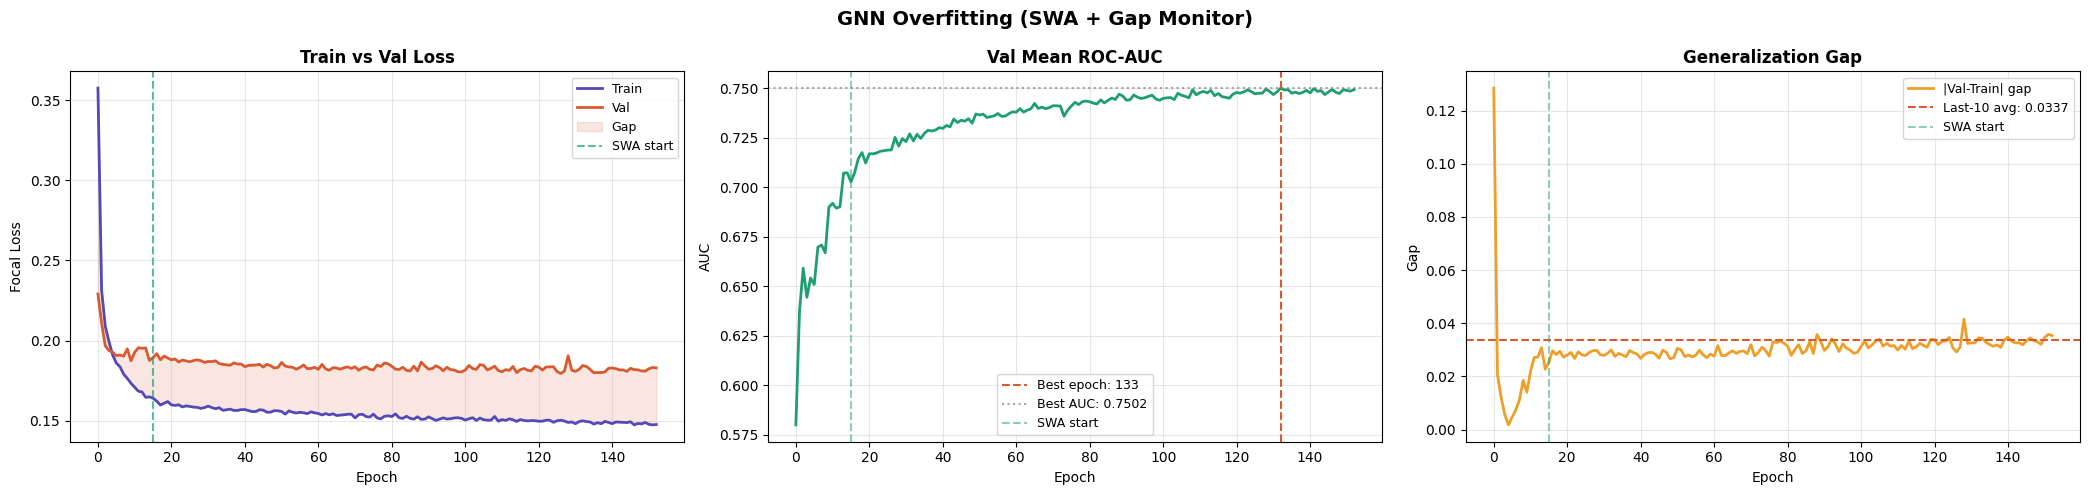

No significant overfitting (gap: 0.0337)


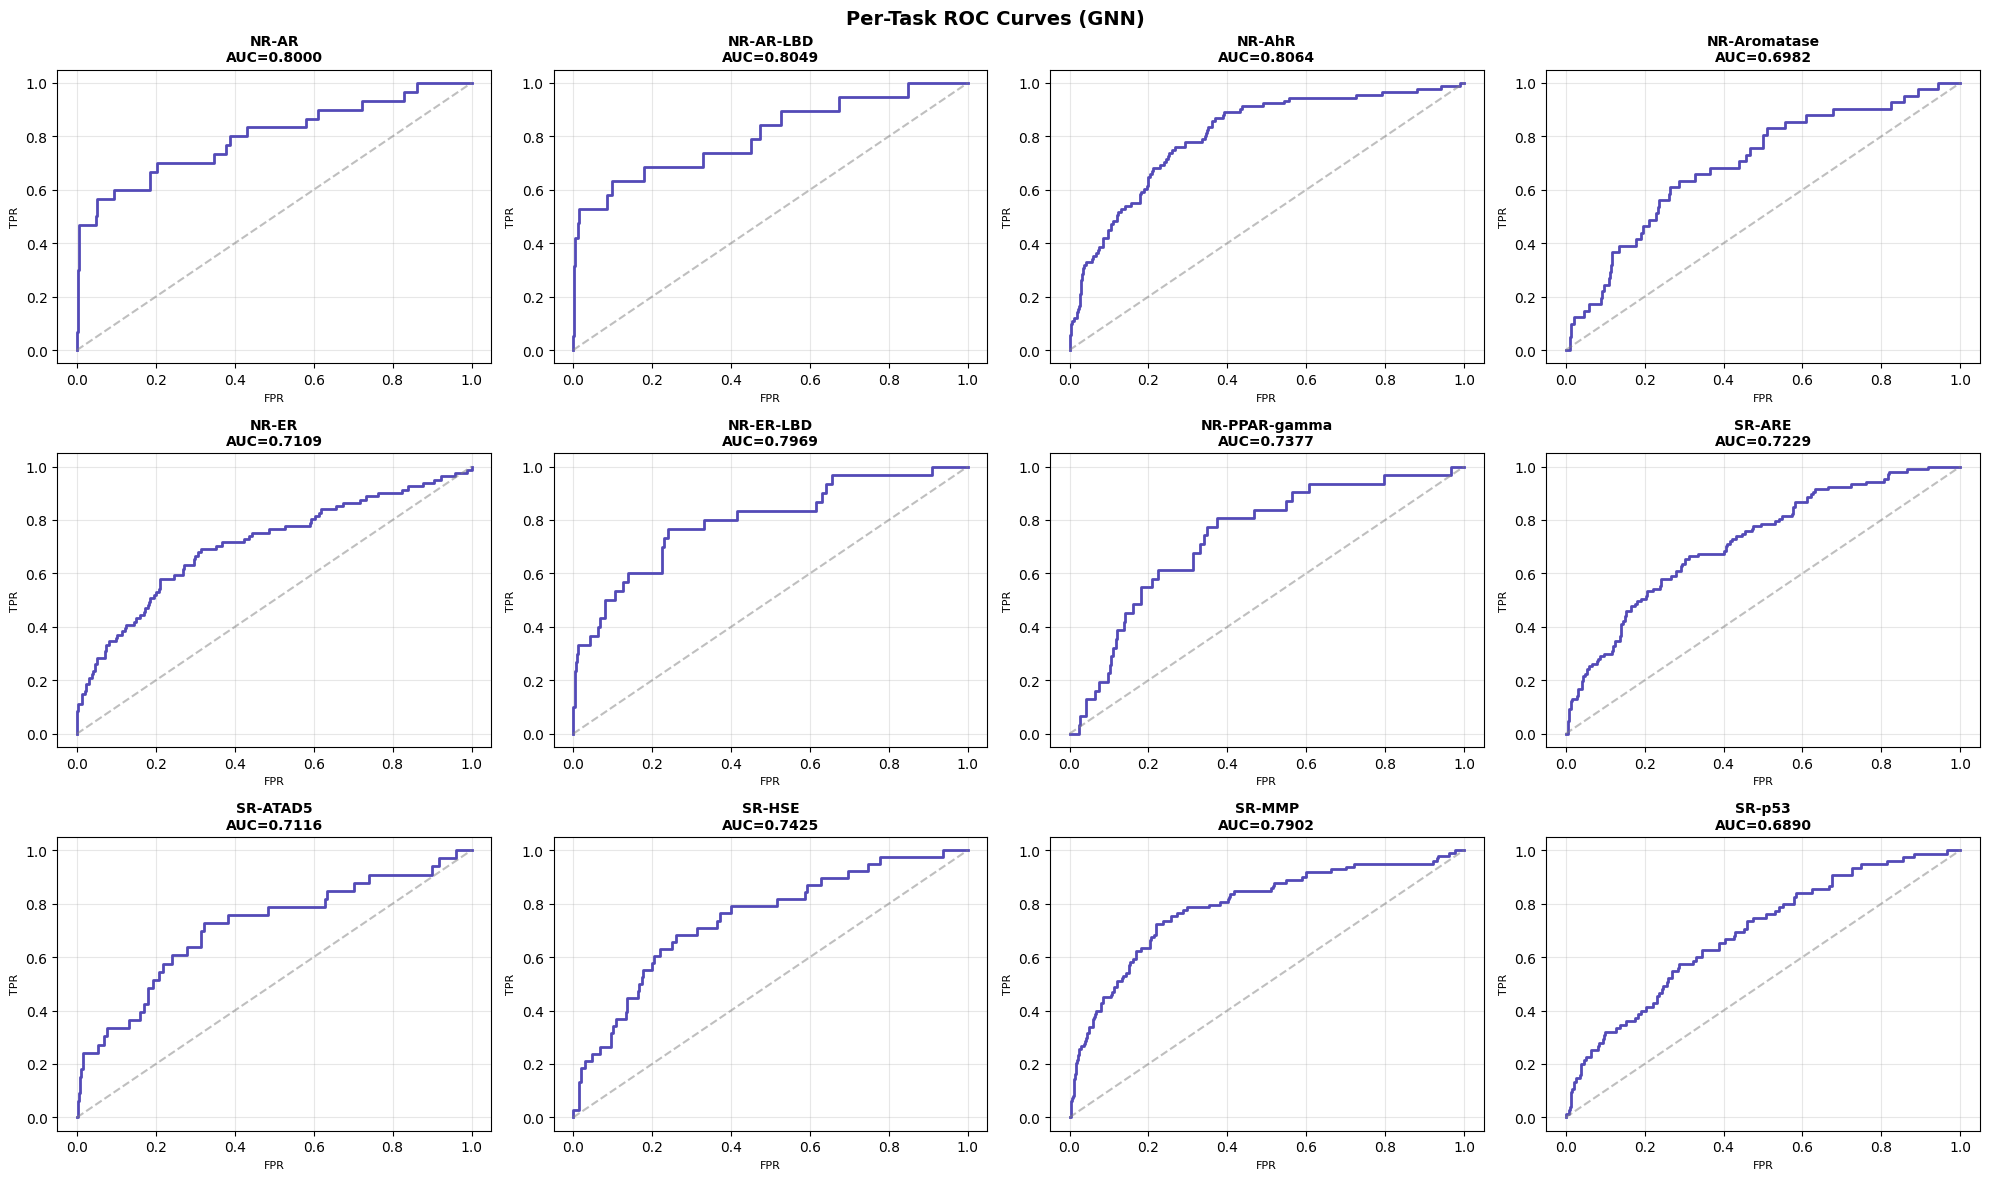

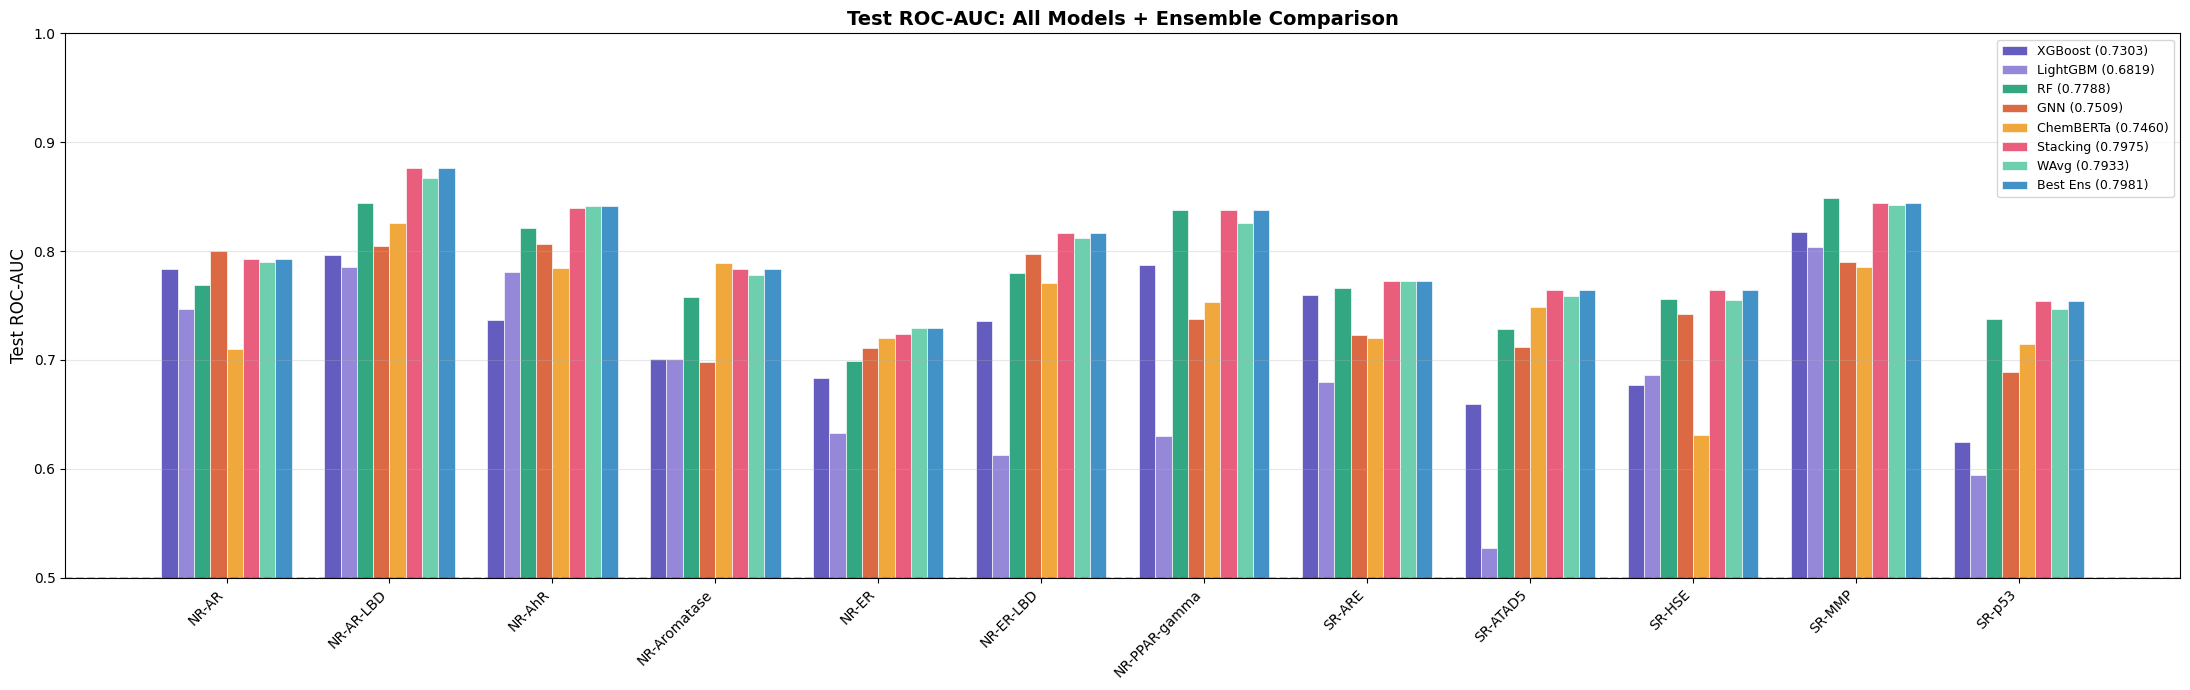


Computing train/val/test AUC on GNN model...


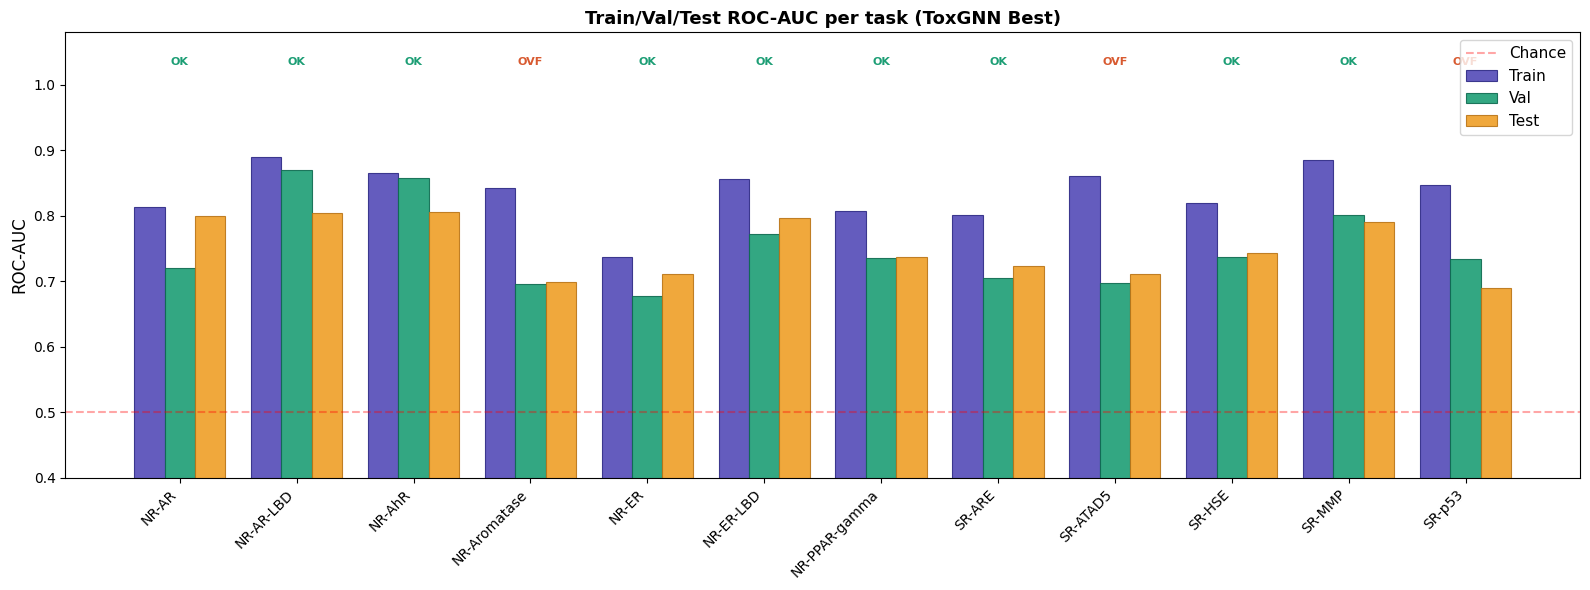


Task                      Train      Val     Test      Gap   Status
------------------------------------------------------------
  NR-AR                  0.8131   0.7200   0.8000   0.0131       OK
  NR-AR-LBD              0.8896   0.8701   0.8049   0.0847       OK
  NR-AhR                 0.8648   0.8569   0.8064   0.0583       OK
  NR-Aromatase           0.8420   0.6961   0.6982   0.1438  OVERFIT
  NR-ER                  0.7375   0.6776   0.7109   0.0266       OK
  NR-ER-LBD              0.8554   0.7720   0.7969   0.0585       OK
  NR-PPAR-gamma          0.8069   0.7361   0.7377   0.0692       OK
  SR-ARE                 0.8015   0.7046   0.7229   0.0786       OK
  SR-ATAD5               0.8601   0.6973   0.7116   0.1485  OVERFIT
  SR-HSE                 0.8202   0.7370   0.7425   0.0777       OK
  SR-MMP                 0.8858   0.8005   0.7902   0.0957       OK
  SR-p53                 0.8467   0.7338   0.6890   0.1577  OVERFIT
------------------------------------------------------

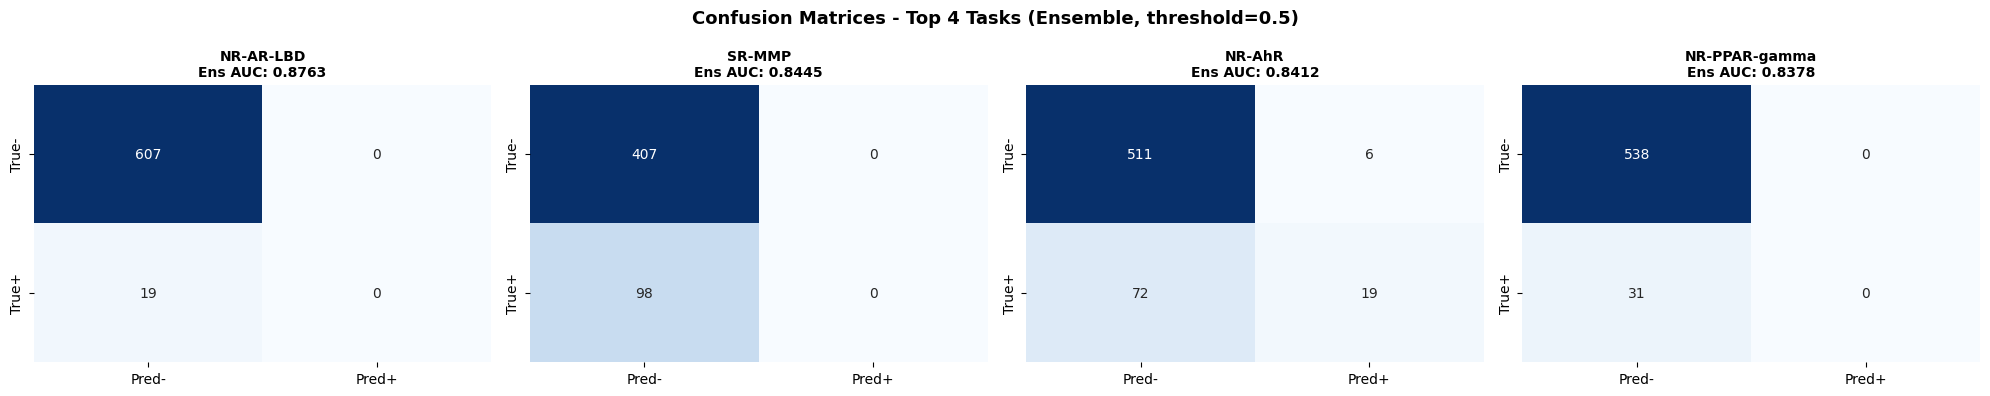


FINAL RESULTS SUMMARY
  Base Models (Test AUC):
    XGBoost:       0.7303
    LightGBM:      0.6819
    Random Forest: 0.7788
    ToxGNN     : 0.7509
    ChemBERTa:     0.7460
  Ensembles (Test AUC):
    Stacking (LR): 0.7975
    Weighted Avg:  0.7933
    Best (per-task): 0.7981

All analysis plots saved to ./data/plots/
DONE.


In [36]:
# CELL 24 - Comprehensive Analysis (5-Model Stacking Ensemble)

from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, auc as sklearn_auc
import seaborn as sns

# ============================================================
# 1. DATASET + FEATURE SUMMARY
# ============================================================
print("=" * 68)
print("DATASET: Tox21 + ZINC250k")
print(f"  Tox21 valid SMILES: {len(df_clean)}")
print(f"  Scaffold split: Train={len(df_train)} | Val={len(df_val)} | Test={len(df_test)}")
print(f"  Features: ECFP4({n_fp_bits}) + MACCS(167) + Topo(2048) + RDKit({len(DESCRIPTOR_LIST)}) + ZINC({len(ZINC_PROPS)}) = {X_train.shape[1]}")
print(f"\n{'Task':<22} {'Labeled':>8} {'Positive':>9} {'Pos%':>6}")
print("  " + "-" * 50)
for task in TOX21_TASKS:
    n_tot = int(df_clean[task].notna().sum()) if task in df_clean.columns else 0
    n_pos = int(df_clean[task].sum()) if task in df_clean.columns else 0
    pct = 100 * n_pos / n_tot if n_tot > 0 else 0
    print(f"  {task:<22} {n_tot:>8} {n_pos:>9} {pct:>5.1f}%")
print("=" * 68)

# ============================================================
# 2. OVERFITTING DIAGNOSTICS (GNN)
# ============================================================
gap = [abs(v - t) for v, t in zip(val_losses, train_losses)]
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

axes[0].plot(train_losses, color='#534AB7', lw=2, label='Train')
axes[0].plot(val_losses, color='#D85A30', lw=2, label='Val')
axes[0].fill_between(range(len(train_losses)), train_losses, val_losses, alpha=0.15, color='#D85A30', label='Gap')
if SWA_START < len(train_losses):
    axes[0].axvline(SWA_START, color='#1D9E75', ls='--', alpha=0.7, label=f'SWA start')
axes[0].set_title('Train vs Val Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Focal Loss'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

best_ep = int(np.argmax(val_aucs_history))
axes[1].plot(val_aucs_history, color='#1D9E75', lw=2)
axes[1].axvline(best_ep, color='#D85A30', ls='--', label=f'Best epoch: {best_ep+1}')
axes[1].axhline(best_val_auc, color='gray', ls=':', alpha=0.7, label=f'Best AUC: {best_val_auc:.4f}')
if SWA_START < len(val_aucs_history):
    axes[1].axvline(SWA_START, color='#1D9E75', ls='--', alpha=0.5, label='SWA start')
axes[1].set_title('Val Mean ROC-AUC', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(gap, color='#EF9F27', lw=2, label='|Val-Train| gap')
last10 = np.mean(gap[-10:]) if len(gap) >= 10 else np.mean(gap)
axes[2].axhline(last10, color='#D85A30', ls='--', label=f'Last-10 avg: {last10:.4f}')
if SWA_START < len(gap):
    axes[2].axvline(SWA_START, color='#1D9E75', ls='--', alpha=0.5, label='SWA start')
axes[2].set_title('Generalization Gap', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Gap'); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('GNN Overfitting (SWA + Gap Monitor)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "overfitting_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

if last10 > 0.10: print(f"WARNING: Overfitting (gap: {last10:.4f})")
elif last10 > 0.05: print(f"Mild overfitting (gap: {last10:.4f})")
else: print(f"No significant overfitting (gap: {last10:.4f})")

# ============================================================
# 3. PER-TASK ROC CURVES (Best Ensemble)
# ============================================================
# Fix: ensure all test graph data is on CPU before DataLoader collation
for g in test_graphs:
    for key in g.keys():
        if isinstance(g[key], torch.Tensor) and g[key].is_cuda:
            g[key] = g[key].cpu()

gnn_eval_model.eval()
gnn_probs_all, targets_all = get_gnn_preds(gnn_eval_model, test_loader, DEVICE, len(TOX21_TASKS))

ncols, nrows = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = axes.flatten()
for t_i, task in enumerate(TOX21_TASKS):
    y_true, y_pred = targets_all[:, t_i], gnn_probs_all[:, t_i]
    mask = ~np.isnan(y_true)
    if mask.sum() < 5:
        axes_flat[t_i].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
        continue
    yt, yp = y_true[mask].astype(int), y_pred[mask]
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_auc = sklearn_auc(fpr, tpr)
    axes_flat[t_i].plot(fpr, tpr, lw=2, color='#534AB7')
    axes_flat[t_i].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
    axes_flat[t_i].set_title(f'{task}\nAUC={roc_auc:.4f}', fontsize=10, fontweight='bold')
    axes_flat[t_i].set_xlabel('FPR', fontsize=8); axes_flat[t_i].set_ylabel('TPR', fontsize=8)
    axes_flat[t_i].grid(alpha=0.3)

plt.suptitle('Per-Task ROC Curves (GNN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "roc_curves_per_task.png"), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. MODEL COMPARISON BAR CHART
# ============================================================
models_dict = {
    'XGBoost': test_aucs_xgb,
    'LightGBM': test_aucs_lgb,
    'RF': test_aucs_rf,
    'GNN': test_aucs_gnn,
    'ChemBERTa': test_aucs_cb,
    'Stacking': test_aucs_stack,
    'WAvg': test_aucs_wavg,
    'Best Ens': test_aucs_ensemble,
}
colors_map = ['#534AB7','#8B7BD4','#1D9E75','#D85A30','#EF9F27','#E74C6F','#5DCAA5','#2E86C1']
tasks_k = list(TOX21_TASKS)
x = np.arange(len(tasks_k))
w = 0.10
fig, ax = plt.subplots(figsize=(22, 7))
for i, (name, aucs_d) in enumerate(models_dict.items()):
    vals = [aucs_d.get(t, np.nan) for t in tasks_k]
    ax.bar(x + i*w - 3.5*w, vals, w, label=f'{name} ({np.nanmean(vals):.4f})',
           color=colors_map[i % len(colors_map)], edgecolor='white', lw=0.5, alpha=0.9)

ax.set_xticks(x); ax.set_xticklabels(tasks_k, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Test ROC-AUC', fontsize=12); ax.set_ylim(0.5, 1.0)
ax.set_title('Test ROC-AUC: All Models + Ensemble Comparison', fontsize=14, fontweight='bold')
ax.axhline(0.5, color='red', ls='--', alpha=0.3); ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "model_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5. ALL MODELS: Train / Val / Test AUC
# ============================================================
print("\nComputing train/val/test AUC on GNN model...")
train_aucs_final = compute_multitask_auc(gnn_eval_model, train_loader, DEVICE)
val_aucs_final   = compute_multitask_auc(gnn_eval_model, val_loader, DEVICE)
test_aucs_final  = {t: test_aucs_gnn.get(t, float('nan')) for t in TOX21_TASKS}

tasks_c = [t for t in TOX21_TASKS if t in train_aucs_final and t in val_aucs_final and t in test_aucs_final]
x = np.arange(len(tasks_c))
w = 0.26

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x-w, [train_aucs_final[t] for t in tasks_c], w, label='Train', color='#534AB7', edgecolor='#2E2A85', lw=0.8, alpha=0.9)
ax.bar(x,   [val_aucs_final[t] for t in tasks_c], w, label='Val', color='#1D9E75', edgecolor='#0E6B50', lw=0.8, alpha=0.9)
ax.bar(x+w, [test_aucs_final[t] for t in tasks_c], w, label='Test', color='#EF9F27', edgecolor='#BA7517', lw=0.8, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(tasks_c, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=12)
gnn_label = 'ToxGNN+SWA' if USE_SWA else 'ToxGNN'
ax.set_title(f'Train/Val/Test ROC-AUC per task ({gnn_label} Best)', fontsize=13, fontweight='bold')
ax.axhline(0.5, color='red', ls='--', alpha=0.35, label='Chance'); ax.set_ylim(0.4, 1.08); ax.legend(fontsize=11)
for i, task in enumerate(tasks_c):
    gap_t = train_aucs_final[task] - test_aucs_final[task]
    if gap_t > 0.10:
        ax.text(x[i], 1.03, 'OVF', ha='center', fontsize=8, color='#D85A30', fontweight='bold')
    else:
        ax.text(x[i], 1.03, 'OK', ha='center', fontsize=8, color='#1D9E75', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "train_val_test_auc.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'Task':<22} {'Train':>8} {'Val':>8} {'Test':>8} {'Gap':>8} {'Status':>8}")
print("-" * 60)
ok_count, ovf_count = 0, 0
for task in tasks_c:
    tr, vl, te = train_aucs_final[task], val_aucs_final[task], test_aucs_final[task]
    gp = tr - te
    ov = "OVERFIT" if gp > 0.10 else "OK"
    if gp > 0.10: ovf_count += 1
    else: ok_count += 1
    print(f"  {task:<20} {tr:>8.4f} {vl:>8.4f} {te:>8.4f} {gp:>8.4f} {ov:>8}")
print("-" * 60)
print(f"  {'MEAN':<20} {np.mean([train_aucs_final[t] for t in tasks_c]):>8.4f} "
      f"{np.mean([val_aucs_final[t] for t in tasks_c]):>8.4f} "
      f"{np.mean([test_aucs_final[t] for t in tasks_c]):>8.4f}")
print(f"\nGNN overfit status: {ok_count} OK / {ovf_count} OVERFIT out of {len(tasks_c)} tasks")

# ============================================================
# 6. CONFUSION MATRICES (top 4 ensemble tasks)
# ============================================================
top4 = sorted(test_aucs_ensemble, key=test_aucs_ensemble.get, reverse=True)[:4]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax_i, task in enumerate(top4):
    ep = ensemble_preds[task]
    yt = ep["true"].astype(int)
    yp = (ep["ensemble"] >= 0.5).astype(int)
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[ax_i], cmap='Blues', cbar=False,
                xticklabels=['Pred-', 'Pred+'], yticklabels=['True-', 'True+'])
    axes[ax_i].set_title(f'{task}\nEns AUC: {test_aucs_ensemble[task]:.4f}', fontweight='bold', fontsize=10)
plt.suptitle('Confusion Matrices - Top 4 Tasks (Ensemble, threshold=0.5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DIRS["plots"], "confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. FINAL SUMMARY
# ============================================================
print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")
print(f"  Base Models (Test AUC):")
print(f"    XGBoost:       {mean_xgb:.4f}")
print(f"    LightGBM:      {mean_lgb:.4f}")
print(f"    Random Forest: {mean_rf:.4f}")
print(f"    ToxGNN{'(SWA)' if USE_SWA else '':>5}: {mean_gnn:.4f}")
if HAS_CB_PREDS:
    print(f"    ChemBERTa:     {mean_cb:.4f}")
print(f"  Ensembles (Test AUC):")
print(f"    Stacking (LR): {mean_stack:.4f}")
print(f"    Weighted Avg:  {mean_wavg:.4f}")
print(f"    Best (per-task): {mean_ens:.4f}")
print(f"{'='*60}")
print(f"\nAll analysis plots saved to {DIRS['plots']}/")
print("DONE.")